<p align="center">
• <a href="https://mayzune.com/"><strong>May Zune</strong></a> •
<a href="https://github.com/hellomayzune"><strong>GitHub</strong></a> •
<a href="https://orcid.org/0000-0003-0282-2633"><strong>ORCID</strong></a> •
<a href="https://scholar.google.com/citations?user=LmP8B_4AAAAJ&hl=en"><strong>Google Scholar</strong></a> •
<a href="https://www.researchgate.net/profile/May-Zune"><strong>ResearchGate</strong></a> •
<a href="https://www.linkedin.com/in/mayzune//"><strong>Linkedin</strong></a> •
</p>

# Week 12 — Black-box Optimisation, Functions 1–8

- success: F1, F4, F5, F7, F8
- fail: F2, F3, F6

## Week 12 Approach

| #  | Surrogate Model                                                                                                                         | Acquisition                                                                                                              | Key Hyperparameters                                                            | Tuning Notes                                                                                                                                         |
| -- | --------------------------------------------------------------------------------------------------------------------------------------- | ------------------------------------------------------------------------------------------------------------------------ | ------------------------------------------------------------------------------ | ---------------------------------------------------------------------------------------------------------------------------------------------------- |
| F1 | GP, Matérn ν=2.5, fixed length scale (from spread of top-3 recent points); target = signed_score transform                              | Dual-arm: UCB (exploit, local grid) + EI (explore, global)                                                               | κ=0.2, ξ=0.5, length scale ≈ geometric estimate                                | Length scale set by geometry, not MLE; signed_score keeps failed negative points ranked correctly                                                    |
| F2 | GP, anisotropic Matérn ν=1.5 + WhiteKernel, MLE-fit (100 restarts)                                                                      | EI vs. observed record, 300k candidates + L-BFGS-B refine, min-distance exclusion                                        | ξ=0.005, length_scale bounds (0.03–1.0), min-dist filter=0.015                 | Tiny ξ since goal is "stay above max" after 3 failed exploration weeks; excludes near-duplicate candidates                                           |
| F3 | Bootstrap ensemble (n=500) of local Ridge models, fit only inside 0.15-radius basin around best                                         | UCB on local perturbations around best point                                                                             | basin_radius=0.15, α=0.02, n_boot=500, search_radius=0.05, κ=1.0               | Switched from global ExtraTrees to a tight local linear model + bootstrap uncertainty                                                                |
| F4 | GP, Constant×Matérn ν=2.5 (learned length scale) + WhiteKernel; chosen via higher log-marginal-likelihood                               | EI vs. best-so-far over mixed pool (σ=0.08/0.02 local + global); final pick restricted to tight (σ=0.02) band            | length_scale bounds (0.05–2.0), noise bounds, perturbation σ=0.08/0.02         | Learned length scale improved fit vs. prior fixed one; final choice deliberately conservative                                                        |
| F5 | SVR (RBF) + GP (Matérn ν=2.5, log1p target), both trained on in-bounds data only, cross-checked via LOO                                 | Pure exploitation — argmax(GP mean); SVR as agreement check only                                                         | SVR: C=100, γ=scale, ε=0.01; GP length_scale=0.3                               | No exploration term — justified by strong monotonic trend toward domain corner (1,1,1,1), which was submitted directly                               |
| F6 | Bootstrap ensemble (n=300) of SVR, hyperparameters via GridSearchCV; bootstrap σ calibrated against LOO residuals                       | EI (ξ=0.01) over 2-stage LHS pool (global → local refine around top 50)                                                  | grid-searched C/γ/ε, calibration factor, ξ=0.01                                | Two-step tuning: SVR hyperparameters (grid search) + separate uncertainty calibration (LOO) before EI                                                |
| F7 | Bootstrap ensemble (n=200) of SVR (manually set C=10, γ=0.5, ε=0.01); selected over RF/GP-residual pipeline via LOOCV comparison        | Check EI (ξ=0.15, set from LOO error scale) over blended pool (tight/medium local + HP1 subspace + global) | C=10, γ=0.5, ε=0.01, ξ=0.15, pool radii 0.08/0.15                              | ξ scaled up ~15× default since model's own CV error (~0.24) makes a near-zero margin meaningless; widened candidate diversity to avoid tunnel vision |
| F8 | MC-Dropout MLP (48 hidden, dropout=0.25), weighted MSE loss (5×/10× for high-y points), σ from 100 MC passes; SHAP for interpretability | UCB with adaptive κ = κ_base × (LOO error/σ ratio) over 50k LHS candidates                                               | hidden=48, dropout=0.25, lr=1e-3, epochs=1500, κ_base=1.0, loss weights 5×/10× | κ self-calibrates from a full weighted LOO retraining loop; loss reweighting focuses capacity on rare high-value region                              |


In [1]:
# Standard Library & Core Imports
import warnings
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import norm
from scipy.optimize import minimize
from scipy.spatial.distance import cdist
from scipy.stats.qmc import LatinHypercube

# PyTorch
import torch
import torch.nn as nn

# Scikit-Learn: Base & Validation
from sklearn.base import clone
from sklearn.exceptions import ConvergenceWarning
from sklearn.model_selection import (
    KFold,
    LeaveOneOut,
    GridSearchCV,
)

# Scikit-Learn: Preprocessing
from sklearn.preprocessing import StandardScaler

# Scikit-Learn: Pipelines
from sklearn.pipeline import Pipeline

# Scikit-Learn: Linear Models
from sklearn.linear_model import Ridge

# Scikit-Learn: Support Vector Machines
from sklearn.svm import SVR

# Scikit-Learn: Ensembles & Trees
from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor,
    ExtraTreesRegressor,
)

# Scikit-Learn: Gaussian Processes
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import (
    Matern,
    WhiteKernel,
    ConstantKernel,
    DotProduct,
)

# Scikit-Learn: Metrics
from sklearn.metrics import mean_absolute_error

# Scikit-Optimize
from skopt.sampler import Lhs
from skopt.space import Space

# Explainability
import shap

# Configuration
warnings.filterwarnings('ignore', category=ConvergenceWarning)

# Helper Functions

In [2]:
# =========================
# Helper Functions
# =========================

def compute_ucb(
    mu: np.ndarray,
    sigma: np.ndarray,
    kappa: float = 2.5,
) -> np.ndarray:
    """Compute Upper Confidence Bound (UCB) acquisition value."""
    return mu + kappa * sigma

def compute_ei(
    mu: np.ndarray,
    sigma: np.ndarray,
    f_best: float,
    xi: int | float = 0.01,
) -> np.ndarray:
    """Compute Expected Improvement (EI) acquisition value."""
    z = (mu - f_best - xi) / (sigma + 1e-9)
    ei = (mu - f_best - xi) * norm.cdf(z) + sigma * norm.pdf(z)
    ei[sigma == 0] = 0
    return ei

def format_query(q) -> str:
    """Format a query vector as a comma-separated NumPy string."""
    return np.array2string(q, precision=6, separator="-")

def signed_score(
    y_arr: np.ndarray | list[float],
    Lmin: float = -300.0,
    Lmax: float = 1.0,
    eps: float = 1e-300,
) -> np.ndarray:
    """Transform values while preserving sign and ordering."""
    y_arr = np.asarray(y_arr, dtype=float)

    L = np.clip(
        np.log10(np.abs(y_arr) + eps),
        Lmin,
        Lmax,
    )

    magnitude = L - Lmin + 1.0

    return np.sign(y_arr) * magnitude

# Optional scikit-optimize support
try:
    from skopt.space import Space
    from skopt.sampler import Lhs

    HAVE_SKOPT = True

except ImportError:
    HAVE_SKOPT = False

def lhs_sample(
    n: int,
    d: int = 5,
    seed: int = 42,
) -> np.ndarray:
    """Generate Latin Hypercube samples in [0, 1]^d."""
    if HAVE_SKOPT:
        space = Space([(0.0, 1.0)] * d)
        lhs = Lhs(criterion="maximin", iterations=100)
        return np.array(
            lhs.generate(space.dimensions, n)
        )

    sampler = qmc.LatinHypercube(
        d=d,
        seed=seed,
    )

    return sampler.random(n=n)

def mc_predict(
    model: torch.nn.Module,
    X_tensor: torch.Tensor,
    n_passes: int = 50,
) -> tuple[np.ndarray, np.ndarray]:
    """Perform Monte Carlo dropout prediction."""
    model.train()

    with torch.no_grad():
        preds = torch.stack(
            [
                model(X_tensor).squeeze()
                for _ in range(n_passes)
            ]
        )

    return (
        preds.mean(dim=0).detach().numpy(),
        preds.std(dim=0).detach().numpy(),
    )

# Function 1, Radiation field, 2D array, 10 original samples - Week 12

In [3]:
# =============================================================================
# Function 1, Radiation field, 2D array, 10 original samples
# =============================================================================
# Previous weeks
# W3: Two-stage strategy: EI balances predicted improvement and uncertainty, 
#      while the distance criterion explicitly promotes spatial diversity, producing an EI + diversity hybrid.
# W4: GP (Matérn ν = 2.5) on log₁₀ outputs + UCB (κ = 5.0, exploration-heavy) --- negative failure
# W5: GP (Matérn ν = 2.5, length scale fixed at 0.15) on log-transformed |outputs|; 
#     acquisition = UCB (κ = 4.0) over 10,000 random candidates
# W6: GP (Matérn, fixed length scale); Signal masking (drop |y| < 1e-30); UCB
# W7: GP (Matérn + White) on log-absolute outputs; UCB κ = 2 --- negative failure
# W8: GP (Matérn + White kernel, optimized hyperparameters) + UCB (κ = 0.5) on tight local candidates
# W9: GP with UCB/EI acquisition and signed, monotonic transform
# W10: Followed Week 9
# W11: GP, Matérn ν=2.5	EI (ξ=0.5), signed-score transform

# changes: exploit close to W8, W9 and W10
#          Use a dual-arm UCB/EI scheme with a geometrically estimated length scale
#          signed-score transform to maintain accurate ranking of failed negative observations.
 
print("=" * 60)
print("Function 1 - Week 12")
print("=" * 60)

# 1. Load data
f1_inputs  = np.load('initial_data/function_1/initial_inputs.npy')
f1_outputs = np.load('initial_data/function_1/initial_outputs.npy')

prev_queries_1 = np.array([
    [0.750000, 0.750000],              # W2
    [0.803076, 0.431805],              # W3
    [0.513943, 0.454749],              # W4 negative failure
    [0.994654, 0.996067],              # W5 (weak but genuine positive detection)
    [0.411304, 0.240532],              # W6
    [0.658199, 0.549042],              # W7 negative failure
    [0.736438, 0.744550],              # W8 return and close to initial
    [0.741762, 0.711733],              # W9 return and above initial best
    [0.718356, 0.714455],              # W10 return and above initial best (current maximum)
    [0.396491, 0.293437],              # W11 return and above initial best (more explore, away from current maximum zone)
])
prev_outputs_1 = np.array([
    1.33E-22,      # W2
    2.04E-50,      # W3
    -3.89E-08,     # W4 negative failure
    5.18E-188,     # W5
    8.07E-24,      # W6
    -7.45E-06,     # W7 negative failure
    2.01E-19,      # W8 return and close to initial
    6.88E-15,      # W9 above initial best
    3.17E-11,      # W10 above initial best
    3.24E-13,      # W11 above initial best
])

all_inputs_F1 = np.vstack([f1_inputs, prev_queries_1])
all_outputs_F1 = np.hstack([f1_outputs, prev_outputs_1])

current_max_idx = np.argmax(all_outputs_F1)
current_max = all_outputs_F1[current_max_idx]
print(f"Total points: {len(all_outputs_F1)}")
print(f"Current max (raw signed value): {current_max:.6e} at {all_inputs_F1[current_max_idx]}")
print("Aim: maximise the output, or at minimum stay above this current max.")

Function 1 - Week 12
Total points: 20
Current max (raw signed value): 3.170000e-11 at [0.718356 0.714455]
Aim: maximise the output, or at minimum stay above this current max.


In [4]:
# Ranking
# Using signed_score, the true current best ranks first, and both negative points fall to the bottom.

scores_F1 = signed_score(all_outputs_F1)
order = np.argsort(scores_F1)[::-1]

print("Ranking — top 5:")
for i in order[:5]:
    print(f"  {all_inputs_F1[i]}  y={all_outputs_F1[i]: .3e}  score={scores_F1[i]:.2f}")
print("\nRanking — bottom 3 (should be the negative failures):")
for i in order[-3:]:
    print(f"  {all_inputs_F1[i]}  y={all_outputs_F1[i]: .3e}  score={scores_F1[i]:.2f}")

assert order[0] == current_max_idx, "Sanity check failed: current best should rank #1"
print("\nSanity check passed: current best now correctly ranks #1.")

Ranking — top 5:
  [0.718356 0.714455]  y= 3.170e-11  score=290.50
  [0.396491 0.293437]  y= 3.240e-13  score=288.51
  [0.741762 0.711733]  y= 6.880e-15  score=286.84
  [0.73102363 0.73299988]  y= 7.711e-16  score=285.89
  [0.736438 0.74455 ]  y= 2.010e-19  score=282.30

Ranking — bottom 3 (should be the negative failures):
  [0.513943 0.454749]  y=-3.890e-08  score=-293.59
  [0.658199 0.549042]  y=-7.450e-06  score=-295.87
  [0.65011406 0.68152635]  y=-3.606e-03  score=-298.56

Sanity check passed: current best now correctly ranks #1.


In [5]:
# Length scale 
# Estimated from the tight cluster of the three most recent good points.

source1_points = np.array([
    [0.736438, 0.744550],              # W8
    [0.741762, 0.711733],              # W9
    [0.718356, 0.714455],              # W10 (current maximum)
])
pairs = [(0, 1), (0, 2), (1, 2)]
dists = [np.linalg.norm(source1_points[i] - source1_points[j]) for i, j in pairs]
ls = np.mean(dists)
print(f"Length scale: {ls:.3f}")

# Fit GP on the (signed) target

kernel_F1 = Matern(nu=2.5, length_scale=ls, length_scale_bounds="fixed")
gp_F1 = GaussianProcessRegressor(kernel=kernel_F1, n_restarts_optimizer=10, normalize_y=True)
gp_F1.fit(all_inputs_F1, scores_F1)

Length scale: 0.031


,kernel,"Matern(length....0306, nu=2.5)"
,alpha,1e-10
,optimizer,'fmin_l_bfgs_b'
,n_restarts_optimizer,10
,normalize_y,True
,copy_X_train,True
,n_targets,None
,random_state,None
,kernel__length_scale,np.float64(0....3972455545562)
,kernel__length_scale_bounds,'fixed'
,kernel__nu,2.5


In [6]:
# Primary recommendation: local exploitation near the known-best cluster

best_pt = all_inputs_F1[current_max_idx]

g = np.linspace(-0.03, 0.03, 121)
G1, G2 = np.meshgrid(g, g)
local_grid = np.clip(best_pt + np.column_stack([G1.ravel(), G2.ravel()]), 0, 1)

mu_local, sigma_local = gp_F1.predict(local_grid, return_std=True)
ucb_local = compute_ucb(mu_local, sigma_local, kappa=0.2)   # exploit-heavy: small kappa keeps
                                                             # us near the predicted peak instead
                                                             # of chasing high-uncertainty edges

best_idx_local = np.argmax(ucb_local)
query_F1 = local_grid[best_idx_local]

print(f"Recommended Week 12 query (exploit): {format_query(query_F1)}")
print(f"  mu={mu_local[best_idx_local]:.1f}  sigma={sigma_local[best_idx_local]:.1f}  "
      f"ucb={ucb_local[best_idx_local]:.1f}")
print(f"  (current best mu at incumbent: {gp_F1.predict(best_pt.reshape(1, -1))[0]:.1f})")
print(f"  distance from current best point: {np.linalg.norm(query_F1 - best_pt):.4f}")

Recommended Week 12 query (exploit): [0.729356-0.715955]
  mu=303.4  sigma=44.9  ucb=312.4
  (current best mu at incumbent: 290.5)
  distance from current best point: 0.0111


In [7]:
# Optional secondary arm: global exploration 

np.random.seed(42)
candidates_F1 = np.random.uniform(0, 1, (50000, 2))
mu_g, sigma_g = gp_F1.predict(candidates_F1, return_std=True)

best_so_far_F1 = scores_F1.max()
ei_g = compute_ei(mu_g, sigma_g, best_so_far_F1, xi=0.5)
best_idx_g = np.argmax(ei_g)
query_F1_explore = candidates_F1[best_idx_g]

print(f"Secondary (explore) query: {format_query(query_F1_explore)}")
print(f"  mu={mu_g[best_idx_g]:.1f}  sigma={sigma_g[best_idx_g]:.1f}  ei={ei_g[best_idx_g]:.1f}")

Secondary (explore) query: [0.410053-0.269502]
  mu=279.6  sigma=154.2  ei=56.0


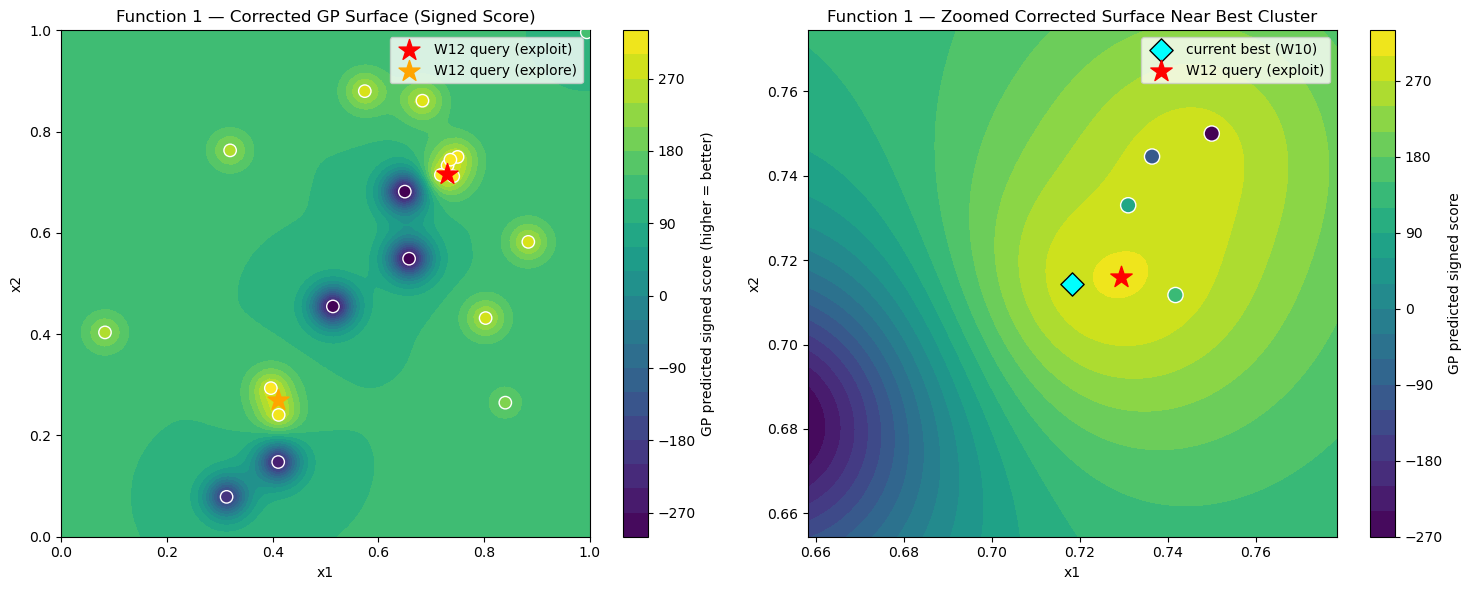

In [8]:
# --- Setup Data & Grids ---
grid_n = 100
x1_grid = np.linspace(0, 1, grid_n)
x2_grid = np.linspace(0, 1, grid_n)
X1, X2 = np.meshgrid(x1_grid, x2_grid)
grid_points = np.column_stack([X1.ravel(), X2.ravel()])

mu_grid, _ = gp_F1.predict(grid_points, return_std=True)
mu_grid = mu_grid.reshape(grid_n, grid_n)

# Zoomed view setup around the known-best cluster
pad = 0.06
x1_zoom = np.linspace(best_pt[0] - pad, best_pt[0] + pad, 100)
x2_zoom = np.linspace(best_pt[1] - pad, best_pt[1] + pad, 100)
X1z, X2z = np.meshgrid(x1_zoom, x2_zoom)
grid_zoom = np.column_stack([X1z.ravel(), X2z.ravel()])
mu_zoom, _ = gp_F1.predict(grid_zoom, return_std=True)
mu_zoom = mu_zoom.reshape(100, 100)

mask = (
    (all_inputs_F1[:, 0] > x1_zoom.min())
    & (all_inputs_F1[:, 0] < x1_zoom.max())
    & (all_inputs_F1[:, 1] > x2_zoom.min())
    & (all_inputs_F1[:, 1] < x2_zoom.max())
)

# --- Combined Side-by-Side Plotting ---
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# --- Plot 1: Full Domain ---
ax1 = axes[0]
cs1 = ax1.contourf(X1, X2, mu_grid, levels=20, cmap='viridis')
fig.colorbar(cs1, ax=ax1, label='GP predicted signed score (higher = better)')
ax1.scatter(
    all_inputs_F1[:, 0],
    all_inputs_F1[:, 1],
    c=scores_F1,
    edgecolors='white',
    s=80,
    cmap='viridis',
    zorder=5,
)
ax1.scatter(
    *query_F1, marker='*', c='red', s=250, zorder=10, label='W12 query (exploit)'
)
ax1.scatter(
    *query_F1_explore,
    marker='*',
    c='orange',
    s=250,
    zorder=10,
    label='W12 query (explore)',
)
ax1.set_xlabel('x1')
ax1.set_ylabel('x2')
ax1.set_title('Function 1 — Corrected GP Surface (Signed Score)')
ax1.legend()

# --- Plot 2: Zoomed View ---
ax2 = axes[1]
cs2 = ax2.contourf(X1z, X2z, mu_zoom, levels=20, cmap='viridis')
fig.colorbar(cs2, ax=ax2, label='GP predicted signed score')
ax2.scatter(
    all_inputs_F1[mask, 0],
    all_inputs_F1[mask, 1],
    c=scores_F1[mask],
    edgecolors='white',
    s=120,
    cmap='viridis',
    zorder=5,
)
ax2.scatter(
    *best_pt,
    marker='D',
    c='cyan',
    s=140,
    zorder=8,
    edgecolors='black',
    label='current best (W10)',
)
ax2.scatter(
    *query_F1, marker='*', c='red', s=260, zorder=10, label='W12 query (exploit)'
)
ax2.set_xlabel('x1')
ax2.set_ylabel('x2')
ax2.set_title('Function 1 — Zoomed Corrected Surface Near Best Cluster')
ax2.legend()

plt.tight_layout()
plt.show()

# Function 2, Noisy Log-Likelihood, 2D array, 10 original samples - Week 12

In [9]:
# =============================================================================
# Function 2, Noisy Log-Likelihood, 2D array, 10 original samples
# =============================================================================
# Previous weeks
# W3: Same GP + EI + distance-maximisation pipeline as F1.
# W4: GP (Matérn + WhiteKernel noise) + Thompson sampling
# W5: Random Forest regression; greedy argmax of predicted mean over 50,000 random candidates
# W6: Random Forest (500 trees, depth 3); Thompson sampling (per-tree)
# W7: Random Forest: Max depth = 3; UCB κ = 1.5; full-ensemble UCB, improving uncertainty estimation
# W8: Anisotropic GP (PDP-derived length-scale bounds from RF) + UCB (κ = 0.1)
# W9: GP with Random Forest-informed kernel parameters; 
#     Adaptive kernel length scales learned from Random Forest partial dependence
# W10: GP (Matérn + White) + posterior-mean maximisation (multi-start L-BFGS-B) with 
#    domain extended to 1.2, plus a manual local search near a target point. --- assignment requirement is 0 to 1.
# W11: GP, Matérn (anisotropic/ARD)	UCB (κ=1.0) with min-distance exclusion

# changes: Apply an anisotropic GP with maximum likelihood estimation 
#         a small EI trade-off parameter to exploit safe gains while avoiding near-duplicate candidates

print("\n" + "=" * 60)
print("Function 2 - Week 12")
print("=" * 60)

f2_inputs = np.load('initial_data/function_2/initial_inputs.npy')
f2_outputs = np.load('initial_data/function_2/initial_outputs.npy')

prev_queries_2 = np.array([
    [1.053349, 0.934354],               # W2 (beyond 0/1 search space)
    [0.660188, 0.32993],                # W3
    [0.729589, 0.938148],               # W4
    [0.685444, 0.332456],               # W5 (above initial max)
    [0.684233, 0.440152],               # W6
    [0.692436, 0.991256],               # W7
    [0.700034, 0.148684],               # W8 (current max, above initial max)
    [0.708298, 0.004444],               # W9 (above initial max)
    [0.697454, 0.000000],               # W10 (fail)
    [0.697793, 0.540885],               # W11 (above initial max)
])
prev_outputs_2 = np.array([-0.040652,          # W2 (worst result)
                           0.468742,           # W3 (fail)
                           0.487563,           # W4 (fail)
                           0.646548,           # W5 (above initial max)
                           0.578337,           # W6 (fail)
                           0.563546,           # W7 (fail)
                           0.683188,           # W8 (current max, above initial max)
                           0.636073,           # W9 (above initial max)
                           0.510942,           # W10 (fail)
                           0.613546,           # W11 (above initial max)
                          ])

all_inputs_F2  = np.vstack([f2_inputs, prev_queries_2])
all_outputs_F2 = np.hstack([f2_outputs, prev_outputs_2])

best_idx_original = np.argmax(all_outputs_F2)
best_y, best_x = all_outputs_F2[best_idx_original], all_inputs_F2[best_idx_original]
print(f"Training points: {len(all_outputs_F2)}")
print(f"Current record:  {best_y:.6f} at x = {best_x}")
print(f"Weeks since last improvement on the record: 3 (W9, W10, W11 all below it)")


Function 2 - Week 12
Training points: 20
Current record:  0.683188 at x = [0.700034 0.148684]
Weeks since last improvement on the record: 3 (W9, W10, W11 all below it)


In [10]:
# GP fit
#   Symmetric length-scale bounds for both dimensions, a single global `WhiteKernel` noise term, 
#     and a tiny numerical `alpha` applied uniformly (no per-point handicapping).

kernel_F2 = (Matern(length_scale=[0.15, 0.15],
                     length_scale_bounds=[(0.03, 1.0), (0.03, 1.0)],
                     nu=1.5)
             + WhiteKernel(noise_level=0.02, noise_level_bounds=(1e-3, 0.2)))

gp_F2 = GaussianProcessRegressor(kernel=kernel_F2, alpha=1e-8,
                                  n_restarts_optimizer=100, normalize_y=True,
                                  random_state=0)
gp_F2.fit(all_inputs_F2, all_outputs_F2)
print("Learned kernel:", gp_F2.kernel_)

nlpds = []
for train_idx, test_idx in KFold(n_splits=5, shuffle=True, random_state=0).split(all_inputs_F2):
    g = clone(gp_F2)
    g.fit(all_inputs_F2[train_idx], all_outputs_F2[train_idx])
    mu, sd = g.predict(all_inputs_F2[test_idx], return_std=True)
    nlpds.append(-norm.logpdf(all_outputs_F2[test_idx], mu, sd).mean())
print(f"5-fold NLPD (clean model): {np.mean(nlpds):.3f}   (raw W12 draft: -0.232)")

mu_best, sd_best = gp_F2.predict(best_x.reshape(1, -1), return_std=True)
print(f"GP belief at the record point itself: {mu_best[0]:.3f} +/- {sd_best[0]:.3f} "
      f"(observed {best_y:.3f}) -> the model thinks part of the record was a lucky noise draw, "
      f"which is exactly why blind exploration keeps missing it.")

Learned kernel: Matern(length_scale=[0.0909, 1], nu=1.5) + WhiteKernel(noise_level=0.0311)
5-fold NLPD (clean model): -0.580   (raw W12 draft: -0.232)
GP belief at the record point itself: 0.643 +/- 0.054 (observed 0.683) -> the model thinks part of the record was a lucky noise draw, which is exactly why blind exploration keeps missing it.


In [11]:
# Acquisition: Expected Improvement over the current record
# Given three failed exploration attempts in a row, EI relative to the observed best 
#     (xi kept small, 0.005, since it needs a genuine improvement, not just a lot of exploration) 
#     is a better match for "stay above the current max" than a UCB with κ=1.5. 
# Candidates within 0.015 of an already-tried point are excluded 
#    so it should not waste the query re-sampling somewhere we already have information about.

def expected_improvement(mu, sd, f_best, xi=0.005):
    z = (mu - f_best - xi) / (sd + 1e-9)
    ei = (mu - f_best - xi) * norm.cdf(z) + sd * norm.pdf(z)
    ei[sd < 1e-6] = 0
    return ei

candidates_F2 = np.random.uniform(0, 1, (300_000, 2))
mu, sd = gp_F2.predict(candidates_F2, return_std=True)
ei = expected_improvement(mu, sd, best_y)

min_dist = cdist(candidates_F2, all_inputs_F2).min(axis=1)
ei[min_dist < 0.015] = -1.0

query_F2 = candidates_F2[np.argmax(ei)]
print("Grid-search EI query:", query_F2)

def neg_ei(x):
    x = np.clip(x, 0, 1)
    m, s = gp_F2.predict(x.reshape(1, -1), return_std=True)
    return -expected_improvement(m, s, best_y)[0]

refined = minimize(neg_ei, query_F2, bounds=[(0, 1), (0, 1)], method='L-BFGS-B')
query_F2 = np.clip(refined.x, 0, 1)
mu_q, sd_q = gp_F2.predict(query_F2.reshape(1, -1), return_std=True)

print(f"\nProposed W12 query: {query_F2}")
print(f"Predicted mean/std at query: {mu_q[0]:.4f} +/- {sd_q[0]:.4f}")
print(f"Expected improvement: {-refined.fun:.4f}")
print(f"Distance to nearest previous query: {cdist(query_F2.reshape(1,-1), all_inputs_F2).min():.4f}")

Grid-search EI query: [0.72024079 0.27980963]

Proposed W12 query: [0.71992353 0.27980615]
Predicted mean/std at query: 0.6537 +/- 0.0855
Expected improvement: 0.0196
Distance to nearest previous query: 0.0629


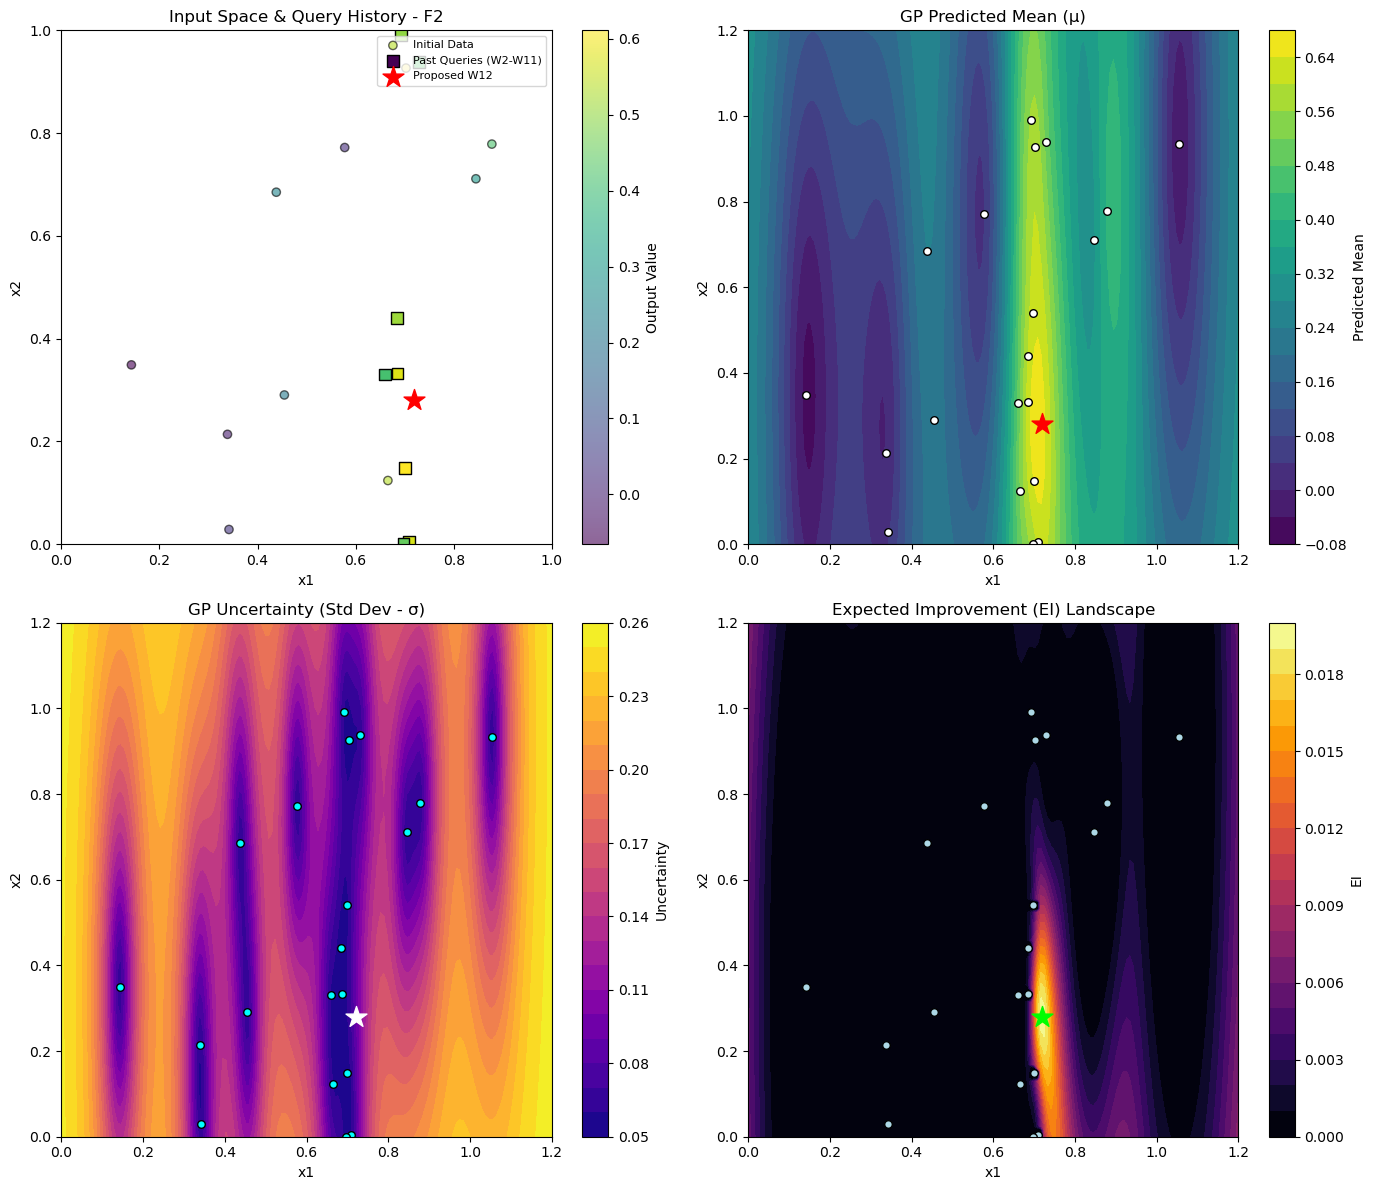

In [12]:
# 1. Create a dense grid for smooth contour plots
resolution = 150
xx, yy = np.meshgrid(
    np.linspace(0, 1.2, resolution), np.linspace(0, 1.2, resolution)
)
grid_pts = np.c_[xx.ravel(), yy.ravel()]

# Evaluate GP and EI on the grid
mu_grid, sd_grid = gp_F2.predict(grid_pts, return_std=True)
ei_grid = expected_improvement(mu_grid, sd_grid, best_y)

# Apply the same distance penalty mask used in your code for EI visualization
min_dist_grid = cdist(grid_pts, all_inputs_F2).min(axis=1)
ei_grid[min_dist_grid < 0.015] = 0

# Reshape for contour plotting
mu_surface = mu_grid.reshape(xx.shape)
sd_surface = sd_grid.reshape(xx.shape)
ei_surface = ei_grid.reshape(xx.shape)

# --- 4-Panel Spatial Dashboard ---
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# Panel 1: Sampling Map
ax = axes[0, 0]
sc1 = ax.scatter(
    f2_inputs[:, 0],
    f2_inputs[:, 1],
    c=f2_outputs,
    cmap="viridis",
    edgecolors="k",
    alpha=0.6,
    label="Initial Data",
)
sc2 = ax.scatter(
    prev_queries_2[:-1, 0],
    prev_queries_2[:-1, 1],
    c=prev_outputs_2[:-1],
    cmap="viridis",
    marker="s",
    s=70,
    edgecolors="k",
    label="Past Queries (W2-W11)",
)
ax.scatter(
    query_F2[0],
    query_F2[1],
    c="red",
    marker="*",
    s=250,
    zorder=5,
    label=f"Proposed W12",
)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_title("Input Space & Query History - F2")
ax.set_xlabel("x1")
ax.set_ylabel("x2")
ax.legend(loc="upper right", fontsize=8)
fig.colorbar(sc1, ax=ax, label="Output Value")

# Panel 2: GP Predicted Mean
ax = axes[0, 1]
cs2 = ax.contourf(xx, yy, mu_surface, levels=20, cmap="viridis")
ax.scatter(
    all_inputs_F2[:, 0],
    all_inputs_F2[:, 1],
    c="white",
    edgecolors="k",
    s=30,
    label="All Evaluated",
)
ax.scatter(
    query_F2[0],
    query_F2[1],
    c="red",
    marker="*",
    s=250,
    zorder=5,
    label="W12",
)
ax.set_title("GP Predicted Mean (μ)")
ax.set_xlabel("x1")
ax.set_ylabel("x2")
fig.colorbar(cs2, ax=ax, label="Predicted Mean")

# Panel 3: GP Uncertainty (Standard Deviation)
ax = axes[1, 0]
cs3 = ax.contourf(xx, yy, sd_surface, levels=20, cmap="plasma")
ax.scatter(
    all_inputs_F2[:, 0],
    all_inputs_F2[:, 1],
    c="cyan",
    edgecolors="k",
    s=30,
    label="All Evaluated",
)
ax.scatter(
    query_F2[0],
    query_F2[1],
    c="white",
    marker="*",
    s=250,
    zorder=5,
    label="W12",
)
ax.set_title("GP Uncertainty (Std Dev - σ)")
ax.set_xlabel("x1")
ax.set_ylabel("x2")
fig.colorbar(cs3, ax=ax, label="Uncertainty")

# Panel 4: Expected Improvement (EI) Landscape
ax = axes[1, 1]
cs4 = ax.contourf(xx, yy, ei_surface, levels=20, cmap="inferno")
ax.scatter(
    all_inputs_F2[:, 0],
    all_inputs_F2[:, 1],
    c="lightblue",
    edgecolors="k",
    s=30,
    label="All Evaluated",
)
ax.scatter(
    query_F2[0],
    query_F2[1],
    c="lime",
    marker="*",
    s=250,
    zorder=5,
    label="Selected W12 (Max EI)",
)
ax.set_title("Expected Improvement (EI) Landscape")
ax.set_xlabel("x1")
ax.set_ylabel("x2")
fig.colorbar(cs4, ax=ax, label="EI")

plt.tight_layout()
plt.show()

# Function 3, A drug discovery project, 3D array, 15 original samples - Week 12

In [13]:
# =============================================================================
# Function 3, A drug discovery project, 3D array, 15 original samples
# =============================================================================
# Previous weeks
# W3: Explicitly mixes exploration (random candidates), local exploitation (perturbations near the best point), 
#     and hypothesis-driven exploitation (directed candidates).
# W4: GP EI (ξ = 0.001, exploitation-biased) blended 50/50 with quadratic polynomial surrogate
# W5: Random Forest trained on degree-2 polynomial features; argmax over 10,000 global candidates
# W6: ExtraTrees (200 trees); Degree-2 polynomial interactions; Argmax over RF predictions
# W7: ExtraTrees + polynomial features; max_features: None vs. sqrt
# W8: ExtraTrees (WLS-weighted, polynomial features) + LCB (κ = 0.5) with exclusion filter
# W9: ExtraTrees surrogate with polynomial feature expansion; Ensemble disagreement and nonlinear feature interactions
# W10: ExtraTrees on log(-Y) + polynomial features, with LCB acquisition (κ = 0.3).
# W11: ExtraTrees (200 trees) on degree-2 polynomial features, log(-Y) target; LCB (κ=0.3), min-distance filter

# changes: Shift to a localised Ridge bootstrap ensemble over narrow neighbourhood perturbations 
#          to obtain focused local uncertainty bounds.

print("\n" + "=" * 60)
print("Function 3 - Week 12")
print("=" * 60)

f3_inputs = np.load('initial_data/function_3/initial_inputs.npy')
f3_outputs = np.load('initial_data/function_3/initial_outputs.npy')

prev_queries_F3 = np.array([
    [0.540087, 0.652622, 0.079307],              # W2
    [0.378956, 0.302768, 0.459346],              # W3
    [0.375610, 0.057061, 0.589980],              # W4
    [0.378956, 0.302768, 0.459346],              # W5
    [0.378956, 0.302768, 0.459346],              # W6 (it was same as W5)
    [0.494932, 0.994690, 0.457121],              # W7
    [0.398479, 0.316913, 0.467387],              # W8
    [0.321464, 0.375442, 0.524156],              # W9
    [0.371804, 0.301322, 0.451223],              # W10
    [0.395514, 0.311838, 0.461924],              # W11
])
prev_outputs_F3 = np.array([
    -0.050615,               # W2 (fail)
    -0.019508,               # W3 (above initial max)
    -0.119425,               # W4  (fail)
    -0.021357,               # W5 (above initial max)
    -0.015072,               # W6 (above initial max, current best)
    -0.069598,               # W7 (fail)
    -0.023447,               # W8 (above initial max)
    -0.029269,               # W9 (above initial max)
    -0.018516,               # W10 (above initial max)
    -0.018112,               # W11 (above initial max)
])

X = np.vstack([f3_inputs, prev_queries_F3])
Y = np.hstack([f3_outputs, prev_outputs_F3])
print(f"Total points: {len(Y)}, best (max): {Y.max():.6f} at {X[np.argmax(Y)]}")

best_point_F3 = X[np.argmax(Y)]


Function 3 - Week 12
Total points: 25, best (max): -0.015072 at [0.378956 0.302768 0.459346]


In [14]:
# Restrict to points inside the proven local-optimum basin
basin_radius = 0.15
d_all = np.linalg.norm(X - best_point_F3, axis=1)
mask = d_all <= basin_radius
X_local, Y_local = X[mask], Y[mask]
print(f"Local basin points used for modelling: {mask.sum()}")

# Bootstrap ensemble of light-regularisation local linear models -> mean + uncertainty (UCB)
rng = np.random.default_rng(0)
n_local = len(Y_local)
alpha = 0.02
n_boot = 500

search_radius = 0.05
n_cand = 20000
offs = rng.normal(0, search_radius / 2, size=(n_cand, 3))
cand = np.clip(best_point_F3 + offs, 0, 1)
dcand = np.linalg.norm(cand - best_point_F3, axis=1)
cand = cand[dcand <= search_radius]
cand = np.vstack([best_point_F3, cand])

boot_preds = np.zeros((n_boot, len(cand)))
for b in range(n_boot):
    idx = rng.integers(0, n_local, n_local)
    ridge = Ridge(alpha=alpha)
    ridge.fit(X_local[idx], Y_local[idx])
    boot_preds[b] = ridge.predict(cand)

mu_F3 = boot_preds.mean(axis=0)
sigma_F3 = boot_preds.std(axis=0)
kappa_F3 = 1.0
ucb_F3 = mu_F3 + kappa_F3 * sigma_F3

top_n = 10
top_idx = np.argsort(ucb_F3)[::-1][:top_n]
print(f"Top {top_n} candidates (bootstrap-UCB, local model, radius={search_radius}):")
for i, idx in enumerate(top_idx):
    dist = np.linalg.norm(cand[idx] - best_point_F3)
    print(f"  {i+1}: {format_query(cand[idx])}  mu={mu_F3[idx]:.6f}  sigma={sigma_F3[idx]:.6f}  "
          f"ucb={ucb_F3[idx]:.6f}  dist={dist:.4f}")

print(f"\n'Repeat current best' baseline: mu={mu_F3[0]:.6f}  sigma={sigma_F3[0]:.6f}  ucb={ucb_F3[0]:.6f}")

query_F3 = cand[top_idx[0]]
print(f"\nProposed Week 12 query: {format_query(query_F3)}")
print(f"Predicted value: {mu_F3[top_idx[0]]:.6f} +/- {sigma_F3[top_idx[0]]:.6f}")

Local basin points used for modelling: 7
Top 10 candidates (bootstrap-UCB, local model, radius=0.05):
  1: [0.403651-0.2712  -0.429849]  mu=-0.018904  sigma=0.001161  ucb=-0.017743  dist=0.0498
  2: [0.404977-0.272696-0.429249]  mu=-0.018906  sigma=0.001163  ucb=-0.017743  dist=0.0499
  3: [0.408292-0.269708-0.43629 ]  mu=-0.018928  sigma=0.001165  ucb=-0.017763  dist=0.0499
  4: [0.40427 -0.276743-0.425407]  mu=-0.018923  sigma=0.001158  ucb=-0.017764  dist=0.0497
  5: [0.399231-0.267536-0.431793]  mu=-0.018919  sigma=0.001152  ucb=-0.017767  dist=0.0491
  6: [0.399149-0.272428-0.426492]  mu=-0.018921  sigma=0.001151  ucb=-0.017770  dist=0.0491
  7: [0.404773-0.269239-0.434477]  mu=-0.018930  sigma=0.001159  ucb=-0.017771  dist=0.0491
  8: [0.398129-0.275248-0.422813]  mu=-0.018923  sigma=0.001149  ucb=-0.017774  dist=0.0496
  9: [0.409035-0.274446-0.432277]  mu=-0.018938  sigma=0.001164  ucb=-0.017775  dist=0.0494
  10: [0.40628 -0.269486-0.43604 ]  mu=-0.018941  sigma=0.001159  ucb=

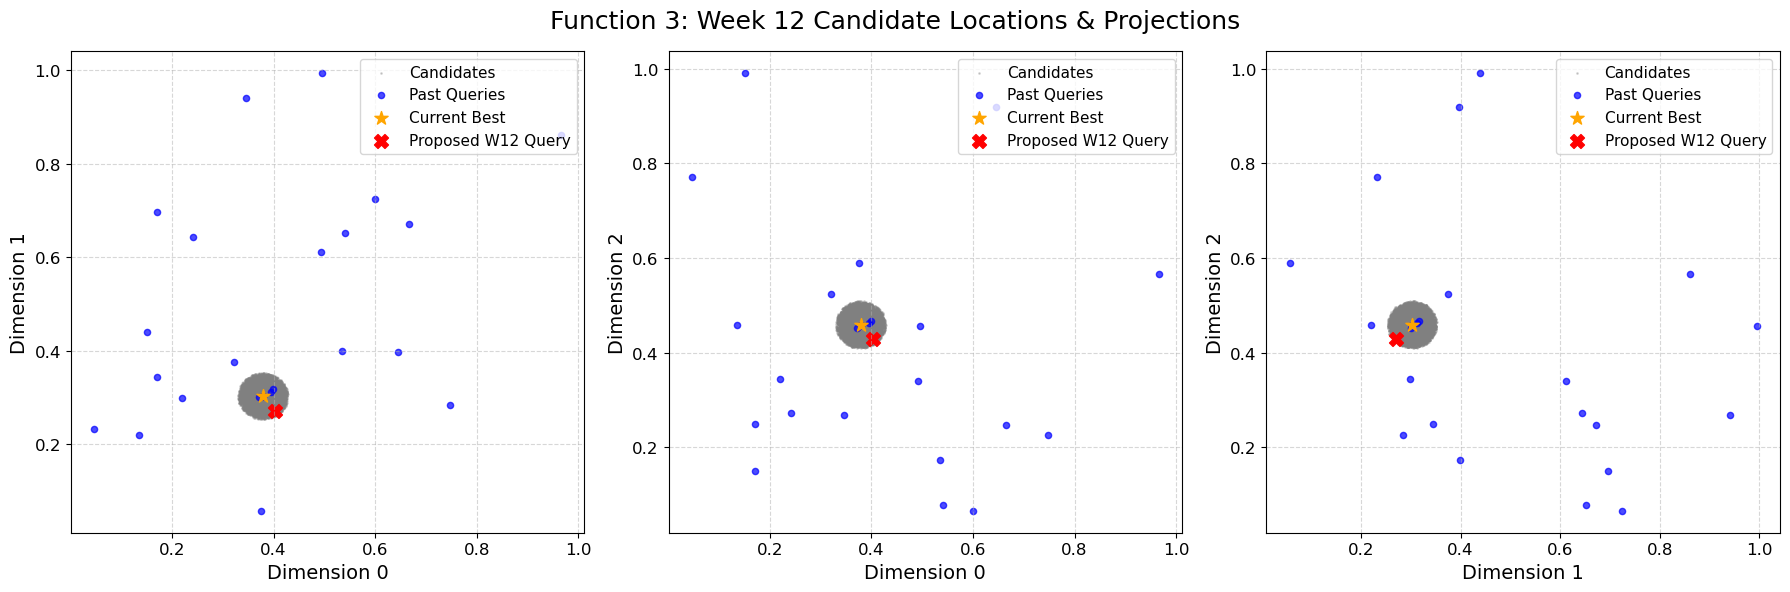

In [15]:
# Visualisation with a multi-panel projection plot
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Projections: X0 vs X1, X0 vs X2, X1 vs X2
pairs = [(0, 1), (0, 2), (1, 2)]
labels = ['Dimension 0', 'Dimension 1', 'Dimension 2']

for ax, (i, j) in zip(axes, pairs):
    # Plot background candidates lightly
    ax.scatter(cand[:, i], cand[:, j], c='gray', s=1, alpha=0.3, label='Candidates')
    # Plot historical queries / data points
    ax.scatter(X[:, i], X[:, j], c='blue', s=20, alpha=0.7, label='Past Queries')
    # Plot best point
    ax.scatter(best_point_F3[i], best_point_F3[j], c='orange', s=100, marker='*', label='Current Best')
    # Plot proposed query (top candidate)
    proposed_query = query_F3
    ax.scatter(proposed_query[i], proposed_query[j], c='red', s=100, marker='X', label='Proposed W12 Query')
    
    ax.set_xlabel(labels[i], fontsize=14)
    ax.set_ylabel(labels[j], fontsize=14)
    ax.tick_params(axis='both', labelsize=12)
    ax.legend(loc='upper right', fontsize=11)
    ax.grid(True, linestyle='--', alpha=0.5)

plt.suptitle('Function 3: Week 12 Candidate Locations & Projections', fontsize=18, y=0.98)
plt.tight_layout()
plt.show()

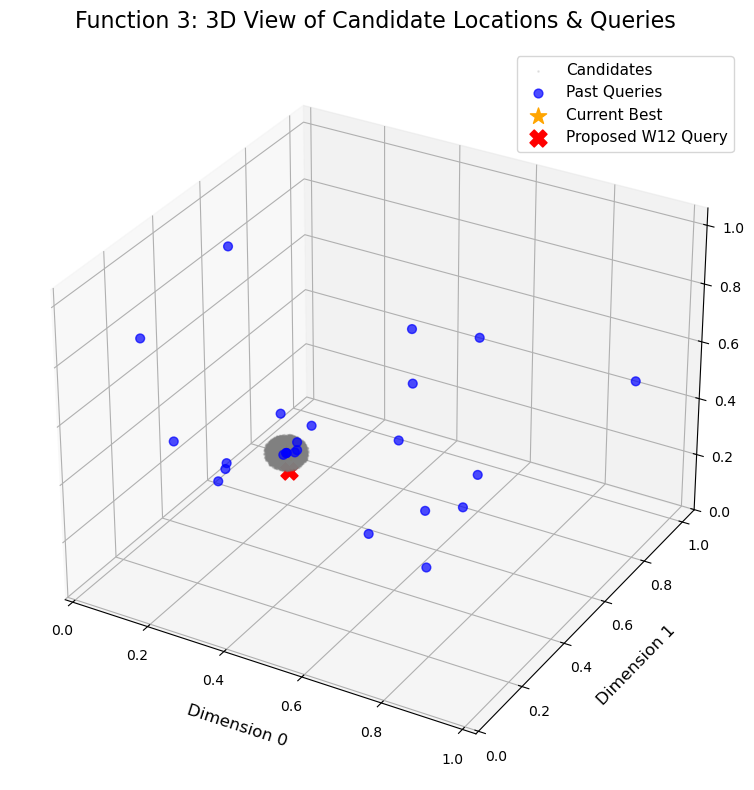

In [16]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(projection='3d')

# Plot background candidates lightly
ax.scatter(cand[:, 0], cand[:, 1], cand[:, 2], c='gray', s=1, alpha=0.15, label='Candidates')

# Plot past queries
ax.scatter(X[:, 0], X[:, 1], X[:, 2], c='blue', s=40, alpha=0.7, label='Past Queries')

# Plot current best
ax.scatter(best_point_F3[0], best_point_F3[1], best_point_F3[2], c='orange', s=150, marker='*', label='Current Best')

# Plot proposed query
proposed_query = query_F3
ax.scatter(proposed_query[0], proposed_query[1], proposed_query[2], c='red', s=150, marker='X', label='Proposed W12 Query')

ax.set_xlabel('Dimension 0', fontsize=12, labelpad=10)
ax.set_ylabel('Dimension 1', fontsize=12, labelpad=10)
ax.set_zlabel('Dimension 2', fontsize=12, labelpad=10)
ax.tick_params(axis='both', which='major', labelsize=10)

ax.set_title('Function 3: 3D View of Candidate Locations & Queries', fontsize=16, pad=15)
ax.legend(loc='upper right', fontsize=11)

plt.tight_layout()
plt.show()

# Function 4, Warehouse business, 4D array, 30 original samples - Week 12

In [17]:
# =============================================================================
# Function 4, Warehouse business, 4D array, 30 original samples
# =============================================================================
# Previous weeks
# W3: Exploration-oriented due to relatively high (UCB, κ = 2.0) over 10k uniformly random candidates.
# W4: GP (Matérn) + Thompson sampling
# W5: RF surrogate; uncertainty estimated from tree-to-tree disagreement (rf_predict_with_std); 
#     acquisition = EI (ξ = 0.01) over Latin Hypercube candidates
# W6: SVM classifier (gate) + ARD GP (refine); Threshold-based binary labelling; EI
# W7: SVM gate + GP (EI); SVM probability threshold; Increased GP α to smooth noisy responses and added global; added global LHS
# W8: GP (Matérn, selected over RF using LOO R²) + UCB (κ = 0.5)
# W9: GP with extensive diagnostic visualisations; Human interpretation of response surfaces guides subsequent exploration
# W10: GP (Matérn, fixed length-scale) with EI computed, 
#      but query actually selected via argmax(mu)— for safe and Pure Exploitation, rather than Expected Improvement.
# W11: GP, Matérn ν=2.5	EI (ξ=0.01), switched from UCB. 
#     Candidate pool built from local perturbations (σ=0.08) around W7/W8 queries + global random, rather than a single scheme.

# changes: Optimise GP length scales via log-marginal-likelihood 
#          select candidates from a tight perturbation band to ensure conservative local exploitation.
 
print("\n" + "=" * 60)
print("Function 4 - Week 12")
print("=" * 60)

f4_inputs  = np.load('initial_data/function_4/initial_inputs.npy')
f4_outputs = np.load('initial_data/function_4/initial_outputs.npy')

prev_queries_F4 = np.array([
    [0.149845, 0.155724, 0.461280, 0.344491],              # W2
    [0.330258, 0.414348, 0.433728, 0.411341],              # W3
    [0.424125, 0.404716, 0.487507, 0.367688],              # W4
    [0.424125, 0.404716, 0.487507, 0.367688],              # W5 so it was the same as Week 4
    [0.255396, 0.450674, 0.468413, 0.490566],              # W6
    [0.371614, 0.422247, 0.370132, 0.421911],              # W7 
    [0.378911, 0.420065, 0.360647, 0.355610],              # W8
    [0.431137, 0.410316, 0.341871, 0.422095],              # W9
    [0.372317, 0.403232, 0.376261, 0.38097],               # W10
    [0.420876, 0.518558, 0.358976, 0.385896],              # W11
])
prev_outputs_F4 = np.array([-7.13212,          # W2 fail
                            0.20379,           # W3 (above initial max)
                            -0.99160,          # W4 (above initial max)
                            -0.99147,          # W5 (above initial max)
                            -3.142015,         # W6 (above initial max)
                            0.657358,          # W7 (above initial max, second best)
                            0.664078,          # W8 (above initial max, so far the best)
                            0.47213,           # W9 (above initial max)
                            0.27362,           # W10 (above initial max)
                            -1.33442,          # W10 (above initial max, but failed against previous week)
                           ]) 

all_inputs_F4  = np.vstack([f4_inputs, prev_queries_F4])
all_outputs_F4 = np.hstack([f4_outputs, prev_outputs_F4])

best_idx = np.argmax(all_outputs_F4)
best_point_so_far = all_inputs_F4[best_idx]
best_val_so_far = all_outputs_F4[best_idx]
print(f"Total points: {len(all_outputs_F4)}, best (max) so far: "
      f"{best_val_so_far:.4f} at {format_query(best_point_so_far)}")


Function 4 - Week 12
Total points: 40, best (max) so far: 0.6641 at [0.378911-0.420065-0.360647-0.35561 ]


In [18]:
# Kernel: learned length_scale + explicit noise term ---

kernel_F4 = (ConstantKernel(1.0, (1e-3, 1e3))
              * Matern(length_scale=0.3, length_scale_bounds=(0.05, 2.0), nu=2.5)
              + WhiteKernel(noise_level=1e-2, noise_level_bounds=(1e-4, 1e1)))
gp_F4 = GaussianProcessRegressor(kernel=kernel_F4, n_restarts_optimizer=20, alpha=1e-6,
                                   normalize_y=True).fit(all_inputs_F4, all_outputs_F4)
print("\nlearned length_scale + explicit noise term:", gp_F4.kernel_)
print("log-marginal-likelihood:", round(gp_F4.log_marginal_likelihood_value_, 3))
print("\n-> The kernel fits the data far better (higher/less-negative LML), so its uncertainty estimates are more trustworthy.")


learned length_scale + explicit noise term: 3.49**2 * Matern(length_scale=1.73, nu=2.5) + WhiteKernel(noise_level=0.00159)
log-marginal-likelihood: -2.855

-> The kernel fits the data far better (higher/less-negative LML), so its uncertainty estimates are more trustworthy.


In [19]:
# Generate candidates: local around the two best queries + a global set

np.random.seed(42)
week7_query = np.array([0.371614, 0.422247, 0.370132, 0.421911])
week8_query = np.array([0.378911, 0.420065, 0.360647, 0.355610])  # current best

cand_w7      = np.array([np.clip(week7_query + np.random.normal(0, 0.08, 4), 0, 1) for _ in range(4000)])
cand_w8      = np.array([np.clip(week8_query + np.random.normal(0, 0.08, 4), 0, 1) for _ in range(4000)])
cand_tight   = np.array([np.clip(week8_query + np.random.normal(0, 0.02, 4), 0, 1) for _ in range(4000)])  # safe, small nudge
cand_global  = np.random.uniform(0, 1, size=(2000, 4))
candidates_F4 = np.vstack([cand_w7, cand_w8, cand_tight, cand_global])
print(f"Candidates: {len(candidates_F4)} total")

Candidates: 14000 total


In [20]:
# Score candidates by Expected Improvement / P(improvement)

mu_F4, sigma_F4 = gp_F4.predict(candidates_F4, return_std=True)
sigma_F4 = np.maximum(sigma_F4, 1e-9)

best_y = best_val_so_far
z_F4 = (mu_F4 - best_y) / sigma_F4
ei_F4 = sigma_F4 * (z_F4 * norm.cdf(z_F4) + norm.pdf(z_F4))
p_improve = 1 - norm.cdf((best_y - mu_F4) /sigma_F4)

ei_idx = np.argmax(ei_F4)
print("\nPipeline pick (EI, recalibrated kernel):")
print(" ", format_query(candidates_F4[ei_idx]))
print(f"  mean={mu_F4[ei_idx]:.3f}  std={sigma_F4[ei_idx]:.3f}  EI={ei_F4[ei_idx]:.4f}  "
      f"P(exceed max)={p_improve[ei_idx]:.3f}")

print(f"\nBest P(exceed max) found anywhere in candidate set: {p_improve.max():.3f}")


Pipeline pick (EI, recalibrated kernel):
  [0.406431-0.362927-0.342631-0.431628]
  mean=0.620  std=0.490  EI=0.1738  P(exceed max)=0.464

Best P(exceed max) found anywhere in candidate set: 0.474


In [21]:
# Recommended Week 12 query: best point in the tight (std=0.02) neighbourhood of the record,
#      ranked by EI, as the safest still-exploratory option.

tight_mask = np.zeros(len(candidates_F4), dtype=bool)
tight_mask[8000:12000] = True   # the cand_tight block
tight_idx = np.where(tight_mask)[0][np.argmax(ei_F4[tight_mask])]

query_F4 = candidates_F4[tight_idx]
print(f"Recommended Week 12 Query: {format_query(query_F4)}")
print(f"  mean={mu_F4[tight_idx]:.3f}  std={sigma_F4[tight_idx]:.3f}  "
      f"EI={ei_F4[tight_idx]:.4f}  P(exceed current max)={p_improve[tight_idx]:.3f}")
print(f"  distance from Week 8 record: {np.linalg.norm(query_F4 - week8_query):.4f}")

Recommended Week 12 Query: [0.380314-0.376647-0.336052-0.410761]
  mean=0.635  std=0.460  EI=0.1692  P(exceed current max)=0.474
  distance from Week 8 record: 0.0744


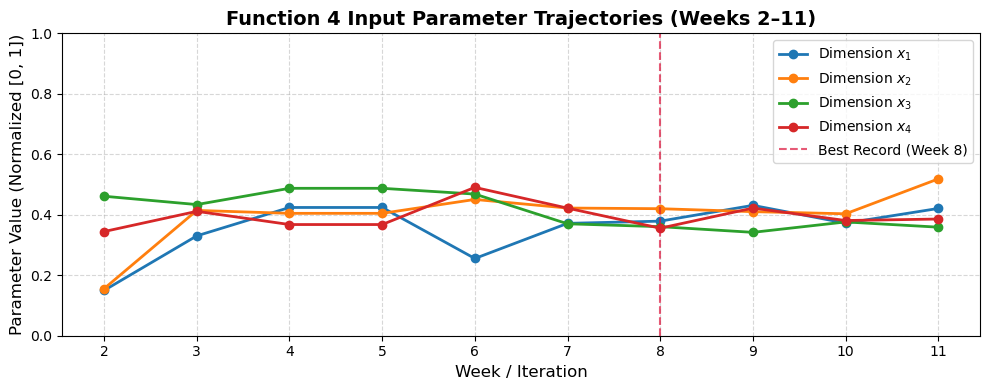

In [22]:
# Let's plot the parameter trajectories for the sequential queries (Weeks 2 to 11)
weeks = list(range(2, 2 + len(prev_queries_F4)))
params = prev_queries_F4.T  # shape (4, 10)

plt.figure(figsize=(10, 4))
for i in range(4):
    plt.plot(weeks, params[i], marker='o', linewidth=2, label=f'Dimension $x_{i+1}$')

plt.axvline(x=8, color='crimson', linestyle='--', alpha=0.7, label='Best Record (Week 8)')

plt.title('Function 4 Input Parameter Trajectories (Weeks 2–11)', fontsize=14, fontweight='bold')
plt.xlabel('Week / Iteration', fontsize=12)
plt.ylabel('Parameter Value (Normalized [0, 1])', fontsize=12)
plt.ylim(0, 1)
plt.xticks(weeks)
plt.legend(frameon=True, loc='upper right')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

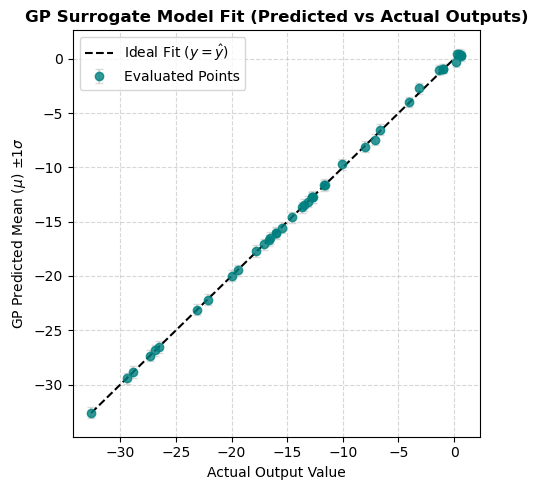

In [23]:
mu_pred, sigma_pred = gp_F4.predict(all_inputs_F4, return_std=True)

plt.figure(figsize=(5, 5))
plt.errorbar(all_outputs_F4, mu_pred, yerr=sigma_pred, fmt='o', color='teal', 
             ecolor='lightgray', elinewidth=1.5, capsize=3, alpha=0.8, label='Evaluated Points')

# Ideal fit line
min_val = min(all_outputs_F4.min(), mu_pred.min())
max_val = max(all_outputs_F4.max(), mu_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], 'k--', label='Ideal Fit ($y = \hat{y}$)')

plt.title('GP Surrogate Model Fit (Predicted vs Actual Outputs)', fontsize=12, fontweight='bold')
plt.xlabel('Actual Output Value', fontsize=10)
plt.ylabel('GP Predicted Mean ($\mu$) $\pm 1\sigma$', fontsize=10)
plt.legend(frameon=True)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

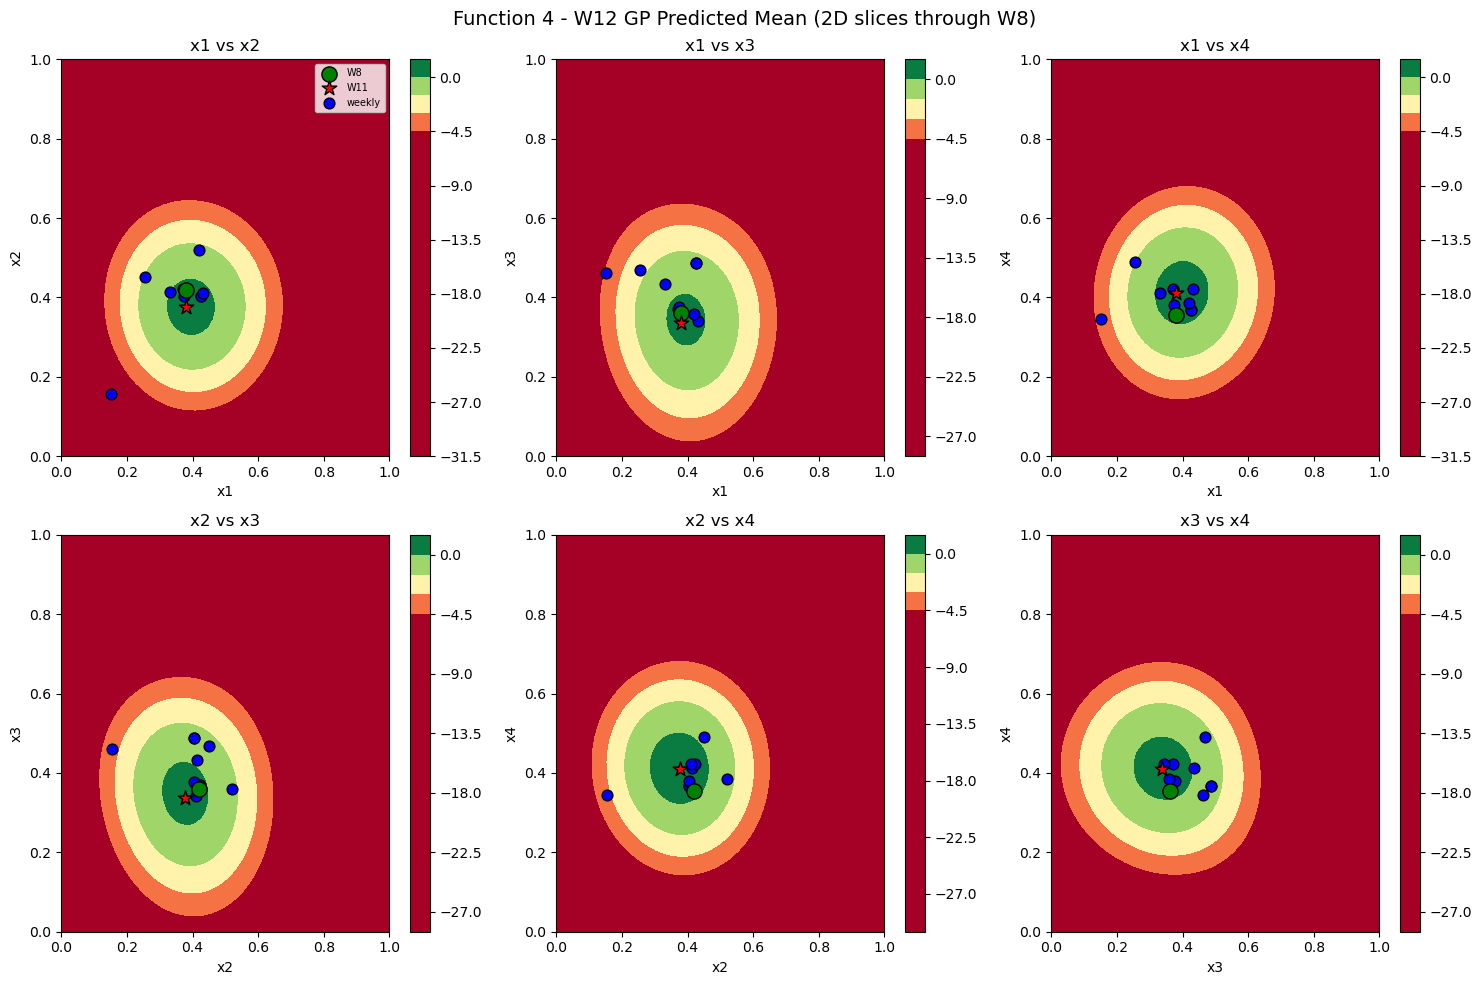

In [24]:
# --- Interpretability plots ---
# 2D GP predicted mean -- sweep pairs of dimensions through W8
dim_names = ['x1', 'x2', 'x3', 'x4']
pairs = [(0,1), (0,2), (0,3), (1,2), (1,3), (2,3)]
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, (d1, d2) in enumerate(pairs):
    ax = axes[idx]
    res = 50
    v1 = np.linspace(0, 1, res)
    v2 = np.linspace(0, 1, res)
    grid = np.tile(week8_query, (res * res, 1))
    g1, g2 = np.meshgrid(v1, v2)
    grid[:, d1] = g1.ravel()
    grid[:, d2] = g2.ravel()

    pred = gp_F4.predict(grid).reshape(res, res)
    contour = ax.contourf(v1, v2, pred, levels=20, cmap='RdYlGn', vmin=-5, vmax=1)
    plt.colorbar(contour, ax=ax)

    ax.scatter(week8_query[d1], week8_query[d2], c='green', edgecolors='black', s=120, zorder=5, label='W8')
    ax.scatter(query_F4[d1], query_F4[d2], c='red', edgecolors='black', s=120, zorder=5, marker='*', label='W11')
    ax.scatter(prev_queries_F4[:, d1], prev_queries_F4[:, d2], c='blue', edgecolors='black', s=60, zorder=4, label='weekly')

    ax.set_xlabel(dim_names[d1])
    ax.set_ylabel(dim_names[d2])
    ax.set_title(f'{dim_names[d1]} vs {dim_names[d2]}')

axes[0].legend(fontsize=7)
plt.suptitle('Function 4 - W12 GP Predicted Mean (2D slices through W8)', fontsize=14)
plt.tight_layout()
plt.show()

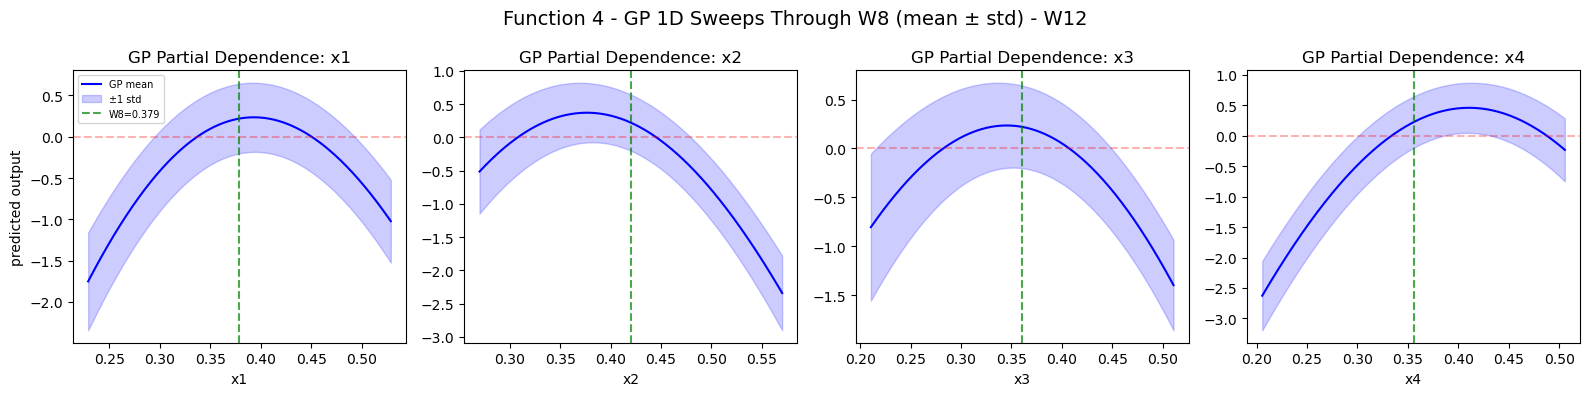

In [25]:
# RF 1D partial dependence through W8 -- shows basin shape per dimension
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for i, ax in enumerate(axes):
    sweep = np.linspace(week8_query[i] - 0.15, week8_query[i] + 0.15, 200)    
    test_points = np.tile(week8_query, (200, 1))
    test_points[:, i] = sweep

    sweep_mu, sweep_std = gp_F4.predict(test_points, return_std=True)

    ax.plot(sweep, sweep_mu, 'b-', label='GP mean')
    ax.fill_between(sweep, sweep_mu - sweep_std, sweep_mu + sweep_std, alpha=0.2, color='blue', label='±1 std')
    ax.axvline(x=week8_query[i], color='green', linestyle='--', alpha=0.7, label=f'W8={week8_query[i]:.3f}')
    ax.axhline(y=0, color='red', linestyle='--', alpha=0.3)
    ax.set_xlabel(dim_names[i])
    ax.set_ylabel('predicted output' if i == 0 else '')
    ax.set_title(f'GP Partial Dependence: {dim_names[i]}')
axes[0].legend(fontsize=7)
plt.suptitle('Function 4 - GP 1D Sweeps Through W8 (mean ± std) - W12', fontsize=14)
plt.tight_layout()
plt.show()

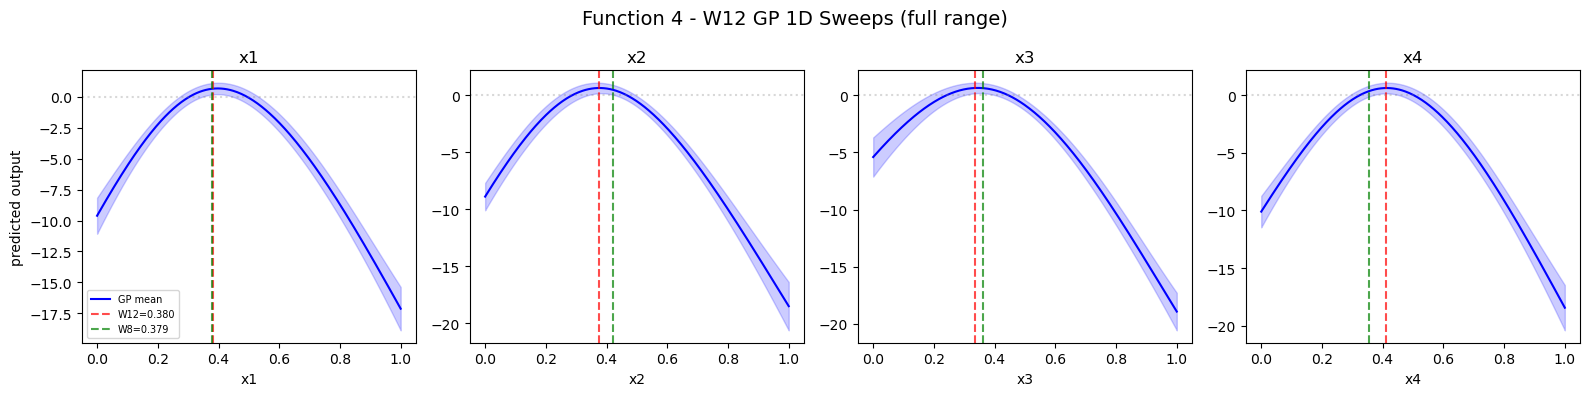

In [26]:
# 1D sweeps with W11 GP
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
dim_names = ['x1', 'x2', 'x3', 'x4']

for i, ax in enumerate(axes):
    sweep = np.linspace(0.0, 1.0, 300)
    test_points = np.tile(query_F4, (300, 1))  # sweep through the W11 query point
    test_points[:, i] = sweep

    sweep_mu, sweep_std = gp_F4.predict(test_points, return_std=True)

    ax.plot(sweep, sweep_mu, 'b-', label='GP mean')
    ax.fill_between(sweep, sweep_mu - sweep_std, sweep_mu + sweep_std, alpha=0.2, color='blue')
    ax.axvline(x=query_F4[i], color='red', linestyle='--', alpha=0.7, label=f'W12={query_F4[i]:.3f}')
    ax.axvline(x=week8_query[i], color='green', linestyle='--', alpha=0.7, label=f'W8={week8_query[i]:.3f}')
    ax.axhline(y=0, color='grey', linestyle=':', alpha=0.3)
    ax.set_xlabel(dim_names[i])
    ax.set_ylabel('predicted output' if i == 0 else '')
    ax.set_title(f'{dim_names[i]}')
axes[0].legend(fontsize=7)
plt.suptitle('Function 4 - W12 GP 1D Sweeps (full range)', fontsize=14)
plt.tight_layout()
plt.show()

# Function 5, Chemical process in a factory, 4D, 20 original samples - Week 12

In [27]:
# =============================================================================
# Function 5, A chemical process in a factory, 4D array, 20 original samples
# =============================================================================
# Previous weeks
# W3: Strong exploitation
#     SVR ranks a locally generated candidate pool (local perturbations and directional moves around the incumbent). 
# W4: Linear regression (search direction) → SVR pre-filter → GP EI (ξ = 0.005)
# W5: Two-stage approach: SVR pre-filters candidates (top 3,000 retained), 
#     then GP (log-transformed outputs, Matérn kernel) evaluates them using EI (ξ = 0.005)
# W6: SVR + GP (log space); Log transform of output; EI
# W7: SVR filter + GP (EI); SVR candidate pool = 3000; EI ξ = 0.005; improving search coverage
# W8: SVR pre-filter (top 3000 candidates) → GP (log-transformed outputs) + EI (ξ = 0.005)
# W9: GP with constrained local and boundary search; Boundary pinning and structured perturbations alter search dynamics
# W10: SVR pre-filter → GP (log1p outputs), EI (ξ=0.005)
#      Out-of-bounds historical points explicitly excluded from training
# W11: 	SVR pre-filter → GP (log1p outputs), EI (ξ=0.005)	
#       SVR: C=100, gamma='scale', epsilon=0.01; GP: length_scale=0.2, n_restarts_optimizer=25

# changes: Employ pure GP mean maximisation validated by SVR cross-checks 
#          to target a clear monotonic trend toward the domain boundary.
 
print("\n" + "=" * 60)
print("Function 5 - Week 12")
print("=" * 60)

f5_inputs  = np.load('initial_data/function_5/initial_inputs.npy')
f5_outputs = np.load('initial_data/function_5/initial_outputs.npy')

prev_queries_F5 = np.array([
    [0.417098, 0.756030, 0.129487, 1.149173],               # W2 (above initial max, beyond 0/1 search space)
    [0.386633, 0.821843, 0.127990, 0.999900],               # W3
    [0.269378, 0.810637, 0.999999, 0.999999],               # W4 (above initial max)
    [0.366671, 0.879874, 0.999999, 0.996800],               # W5 (above initial max)
    [0.495228, 0.809693, 0.999999, 0.999990],               # W6 (above initial max)
    [0.382122, 0.995456, 0.999999, 0.999999],               # W7 (above initial max)
    [0.566703, 0.999727, 0.999999, 0.999999],               # W8 (above initial max)
    [0.626657, 0.999999, 0.999999, 0.999999],               # W9 (best)
    [0.656411, 1.185597, 1.026548, 1.160768],               # W10 (best, but beyond 0 to 1 search space)
    [0.847572, 1.000000, 1.000000, 1.000000],               # W11 (above initial max)
])
prev_outputs_F5 = np.array([1829.809875,                    # W2 (above initial max, beyond 0/1 search space)
                            710.602251,                     # W3 (fail)
                            2699.104490,                    # W4 (above initial max)
                            3179.389393,                    # W5 (above initial max)
                            2855.140103,                    # W6 (above initial max)
                            4461.243621,                    # W7 (above initial max)
                            4826.282687,                    # W8 (above initial max) 
                            5022.767511,                    # W9 (best)
                            14653.360405,                   # W10 (best, but beyond 0 to 1 search space)
                            6469.995029,                    # W11 (above initial max) 
                           ])

all_inputs_F5  = np.vstack([f5_inputs, prev_queries_F5])
all_outputs_F5 = np.hstack([f5_outputs, prev_outputs_F5])

# --- Strict bounds check: task requires every query in [0, 1]^4 ---
oob_mask   = (all_inputs_F5 < 0).any(axis=1) | (all_inputs_F5 > 1).any(axis=1)
valid_mask = ~oob_mask

Xv = all_inputs_F5[valid_mask]
Yv = all_outputs_F5[valid_mask]

print(f"Total historical points: {len(all_outputs_F5)}")
print(f"Out-of-bounds (excluded from modelling entirely): {oob_mask.sum()}")
print(f"Valid in-bounds points used for modelling: {len(Yv)}")

best_idx = np.argmax(Yv)
CURRENT_BEST_VALID = Yv[best_idx]
print(f"\nCurrent best VALID (achievable) output: {CURRENT_BEST_VALID:.4f}")
print(f"At point: {np.round(Xv[best_idx], 6)}")


Function 5 - Week 12
Total historical points: 30
Out-of-bounds (excluded from modelling entirely): 2
Valid in-bounds points used for modelling: 28

Current best VALID (achievable) output: 6469.9950
At point: [0.847572 1.       1.       1.      ]


In [28]:
# Trend check

order = np.argsort(-Yv)
print(f"{'x1':>9} {'x2':>9} {'x3':>9} {'x4':>9}   output")
for idx in order[:10]:
    x = Xv[idx]
    print(f"{x[0]:9.4f} {x[1]:9.4f} {x[2]:9.4f} {x[3]:9.4f}   {Yv[idx]:10.2f}")

       x1        x2        x3        x4   output
   0.8476    1.0000    1.0000    1.0000      6470.00
   0.6267    1.0000    1.0000    1.0000      5022.77
   0.5667    0.9997    1.0000    1.0000      4826.28
   0.3821    0.9955    1.0000    1.0000      4461.24
   0.3667    0.8799    1.0000    0.9968      3179.39
   0.4952    0.8097    1.0000    1.0000      2855.14
   0.2694    0.8106    1.0000    1.0000      2699.10
   0.2242    0.8465    0.8795    0.8785      1088.86
   0.3866    0.8218    0.1280    0.9999       710.60
   0.1199    0.8625    0.6433    0.8498       431.61


In [29]:
# --- Surrogate 1: SVR on standardised inputs/outputs, valid data only ---
input_scaler  = StandardScaler()
output_scaler = StandardScaler()
X_scaled = input_scaler.fit_transform(Xv)
Y_scaled = output_scaler.fit_transform(Yv.reshape(-1, 1)).ravel()

svr_F5 = SVR(kernel='rbf', C=100, gamma='scale', epsilon=0.01)
svr_F5.fit(X_scaled, Y_scaled)

# --- Surrogate 2: GP on log1p-transformed outputs, valid data only ---
y_log = np.log1p(Yv)
kernel_gp = (ConstantKernel(1.0, (1e-3, 1e3)) *
             Matern(length_scale=0.3, length_scale_bounds=(0.05, 2.0), nu=2.5) +
             WhiteKernel(1e-3, (1e-6, 1.0)))
gp_F5 = GaussianProcessRegressor(kernel=kernel_gp, n_restarts_optimizer=30,
                                  normalize_y=True, random_state=0)
gp_F5.fit(Xv, y_log)
print("Fitted kernel:", gp_F5.kernel_)

Fitted kernel: 1.55**2 * Matern(length_scale=0.856, nu=2.5) + WhiteKernel(noise_level=1e-06)


In [30]:
# Leave-one-out cross-validation
# Before trusting the surrogate's recommendation, check that it can actually predict held-out points reasonably well on data I have.

loo = LeaveOneOut()
errs = []
for tr, te in loo.split(Xv):
    k = (ConstantKernel(1.0, (1e-3, 1e3)) *
         Matern(length_scale=0.3, length_scale_bounds=(0.05, 2.0), nu=2.5) +
         WhiteKernel(1e-3, (1e-6, 1.0)))
    gp_cv = GaussianProcessRegressor(kernel=k, n_restarts_optimizer=5,
                                      normalize_y=True, random_state=0)
    gp_cv.fit(Xv[tr], y_log[tr])
    pred = np.expm1(gp_cv.predict(Xv[te]))[0]
    errs.append(pred - Yv[te][0])

errs = np.array(errs)
print(f"LOO mean absolute error: {np.mean(np.abs(errs)):.2f}")
print(f"LOO RMSE:                {np.sqrt(np.mean(errs**2)):.2f}")
print(f"(for reference, valid outputs range {Yv.min():.2f} to {Yv.max():.2f}, mean {Yv.mean():.2f})")

LOO mean absolute error: 139.51
LOO RMSE:                333.53
(for reference, valid outputs range 0.11 to 6470.00, mean 1187.50)


In [31]:
# --- Candidate search: strictly generated inside [0,1]^4, never outside ---
best_point = Xv[np.argmax(Yv)]

local = np.clip(best_point + np.random.normal(0, 0.05, size=(6000, 4)), 0.0, 1.0)
directed = np.tile(best_point, (4000, 1))
directed[:, 0] = np.clip(directed[:, 0] + np.abs(np.random.normal(0, 0.15, 4000)), 0.0, 1.0)
directed[:, 1] = np.clip(directed[:, 1] + np.abs(np.random.normal(0, 0.05, 4000)), 0.0, 1.0)
directed[:, 2] = np.clip(directed[:, 2] + np.abs(np.random.normal(0, 0.05, 4000)), 0.0, 1.0)
directed[:, 3] = np.clip(directed[:, 3] + np.abs(np.random.normal(0, 0.05, 4000)), 0.0, 1.0)
uniform = np.random.uniform(0.0, 1.0, size=(20000, 4))   # broad in-bounds exploration
corner  = np.array([[1.0, 1.0, 1.0, 1.0]])                # explicit candidate suggested by the trend

candidates_F5 = np.vstack([local, directed, uniform, corner])
assert (candidates_F5 >= 0).all() and (candidates_F5 <= 1).all(), "candidate left [0,1] bounds!"

mu_log, sigma_log = gp_F5.predict(candidates_F5, return_std=True)
mu = np.expm1(mu_log)

svr_pred_s = svr_F5.predict(input_scaler.transform(candidates_F5))
svr_pred   = output_scaler.inverse_transform(svr_pred_s.reshape(-1, 1)).ravel()

best_idx_F5 = np.argmax(mu)
query_F5 = candidates_F5[best_idx_F5]

print(f"GP-selected Week 12 query: {format_query(query_F5)}")
print(f"GP predicted yield:  {mu[best_idx_F5]:.2f}  (log-scale std: {sigma_log[best_idx_F5]:.4f})")
print(f"SVR predicted yield at that point: {svr_pred[best_idx_F5]:.2f}")
print(f"\nFor comparison, GP/SVR at the exact corner (1,1,1,1):")
mu_corner, s_corner = gp_F5.predict(corner, return_std=True)
svr_corner = output_scaler.inverse_transform(
    svr_F5.predict(input_scaler.transform(corner)).reshape(-1, 1)).ravel()[0]
print(f"  GP:  {np.expm1(mu_corner)[0]:.2f} (std {s_corner[0]:.4f})   SVR: {svr_corner:.2f}")

GP-selected Week 12 query: [0.976764-1.      -1.      -1.      ]
GP predicted yield:  6943.75  (log-scale std: 0.2775)
SVR predicted yield at that point: 6923.02

For comparison, GP/SVR at the exact corner (1,1,1,1):
  GP:  6926.60 (std 0.3468)   SVR: 6918.44


In [32]:
final_query_F5 = np.array([1.0, 1.0, 1.0, 1.0])
assert (final_query_F5 >= 0).all() and (final_query_F5 <= 1).all()
print(f"Week 12 Query (Function 5): {format_query(final_query_F5)}")
print(f"Current best-to-beat: {CURRENT_BEST_VALID:.4f}")

Week 12 Query (Function 5): [1.-1.-1.-1.]
Current best-to-beat: 6469.9950


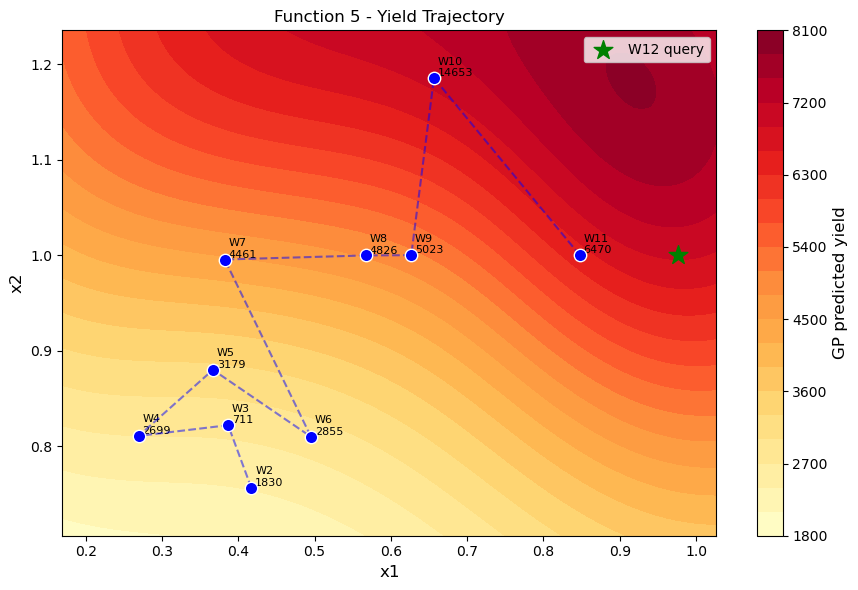

In [33]:
# Plot a 2D contour (x1 vs x2, with x3/x4 held near 1) of the GP's predicted yield,
#  overlaying the historical query trajectory and the UCB-selected W10 query 
#  to visualise the search path as it moves beyond the original [0,1] bounds.

pad = 0.05
x1_min = min(prev_queries_F5[:, 0].min(), query_F5[0]) - 0.1
x1_max = max(prev_queries_F5[:, 0].max(), query_F5[0]) + pad
x2_min = min(prev_queries_F5[:, 1].min(), query_F5[1]) - pad
x2_max = max(prev_queries_F5[:, 1].max(), query_F5[1]) + pad

grid_n = 80
x1_range = np.linspace(x1_min, x1_max, grid_n)
x2_range = np.linspace(x2_min, x2_max, grid_n)
X1_g, X2_g = np.meshgrid(x1_range, x2_range)

grid_4d = np.column_stack([X1_g.ravel(), X2_g.ravel(),
                           np.full(grid_n**2, 0.999999),
                           np.full(grid_n**2, 0.999999)])
mu_grid = np.expm1(gp_F5.predict(grid_4d))
mu_grid = mu_grid.reshape(grid_n, grid_n)

fig, ax = plt.subplots(figsize=(9, 6))
cf = ax.contourf(X1_g, X2_g, mu_grid, levels=20, cmap='YlOrRd')
cbar = fig.colorbar(cf)
cbar.set_label('GP predicted yield', fontsize=12)

for i in range(len(prev_queries_F5)):
    ax.scatter(prev_queries_F5[i, 0], prev_queries_F5[i, 1], c='blue',
               edgecolors='white', s=80, zorder=5)
    ax.annotate(f'W{i+2}\n{prev_outputs_F5[i]:.0f}',   # no data for W1
                (prev_queries_F5[i, 0] + 0.005, prev_queries_F5[i, 1] + 0.002), fontsize=8)
ax.plot(prev_queries_F5[:, 0], prev_queries_F5[:, 1], 'b--', alpha=0.5, zorder=4)
ax.scatter(query_F5[0], query_F5[1], marker='*', c='green', s=200, zorder=10, label='W12 query')

ax.set_xlabel('x1', fontsize=12)
ax.set_ylabel('x2', fontsize=12)
ax.set_title('Function 5 - Yield Trajectory')
ax.legend()
fig.tight_layout()
plt.show()

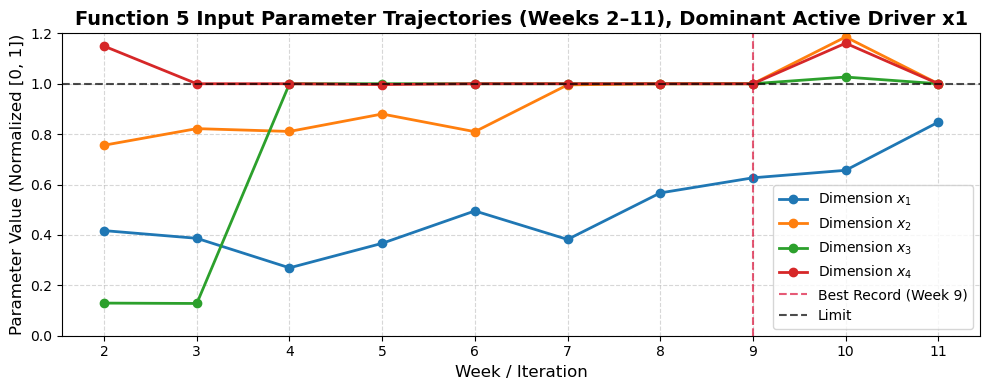

In [34]:
# Let's plot the parameter trajectories for the sequential queries (Weeks 2 to 11)
weeks = list(range(2, 2 + len(prev_queries_F5)))
params = prev_queries_F5.T  # shape (4, 10)

plt.figure(figsize=(10, 4))
for i in range(4):
    plt.plot(weeks, params[i], marker='o', linewidth=2, label=f'Dimension $x_{i+1}$')

plt.axvline(x=9, color='crimson', linestyle='--', alpha=0.7, label='Best Record (Week 9)')
plt.axhline(y=1, color='black', linestyle='--', alpha=0.7, label='Limit')

plt.title('Function 5 Input Parameter Trajectories (Weeks 2–11), Dominant Active Driver x1', fontsize=14, fontweight='bold')
plt.xlabel('Week / Iteration', fontsize=12)
plt.ylabel('Parameter Value (Normalized [0, 1])', fontsize=12)
plt.ylim(0, 1.2)
plt.xticks(weeks)
plt.legend(frameon=True, loc='lower right')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

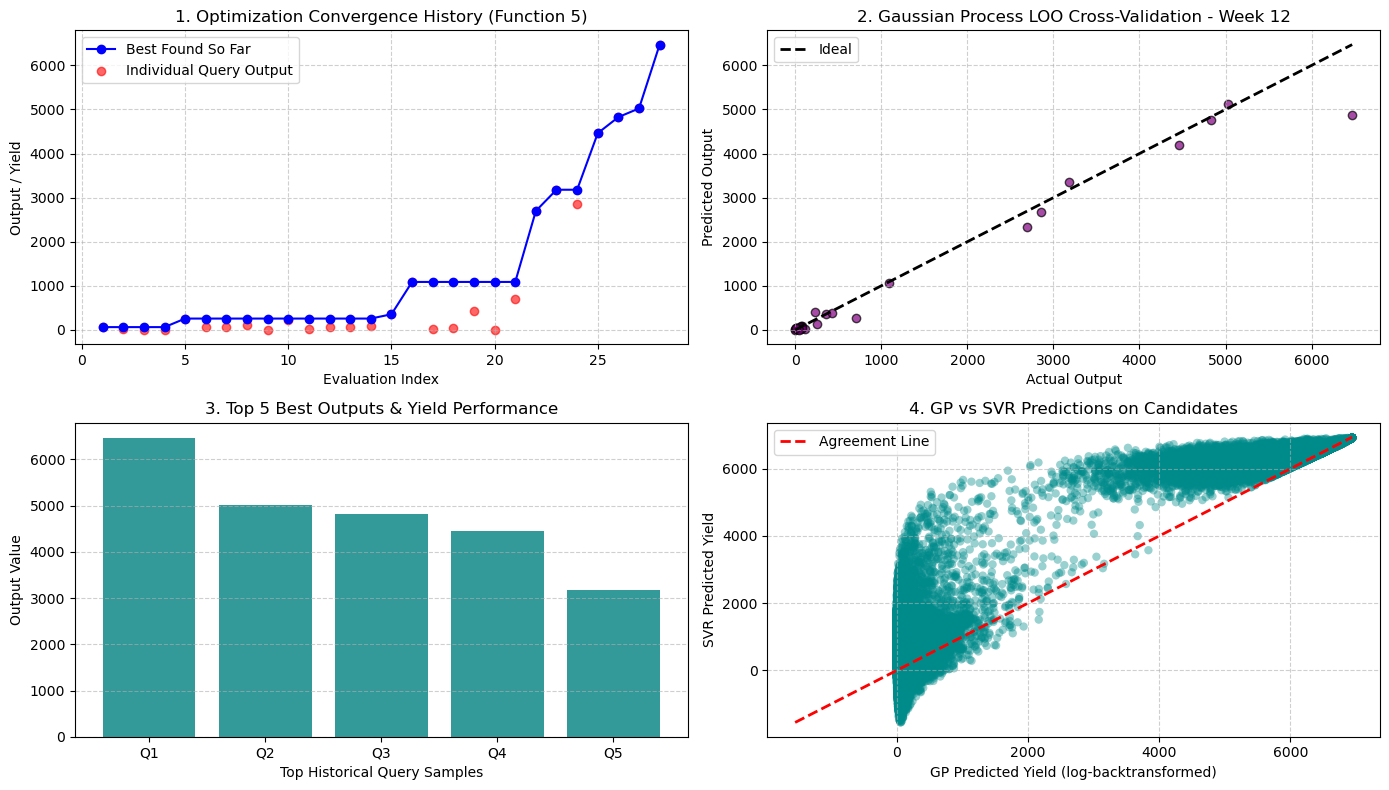

In [35]:
# Set up the 2x2 subplot layout
fig, axs = plt.subplots(2, 2, figsize=(14, 8))

# --- Plot 1: Optimization Convergence History (Top-Left) ---
axs[0, 0].plot(range(1, len(Yv) + 1), np.maximum.accumulate(Yv), marker='o', color='b', label='Best Found So Far')
axs[0, 0].scatter(range(1, len(Yv) + 1), Yv, color='red', alpha=0.6, label='Individual Query Output')
axs[0, 0].set_title('1. Optimization Convergence History (Function 5)')
axs[0, 0].set_xlabel('Evaluation Index')
axs[0, 0].set_ylabel('Output / Yield')
axs[0, 0].grid(True, linestyle='--', alpha=0.6)
axs[0, 0].legend()

# --- Plot 2: Gaussian Process LOO Cross-Validation (Top-Right) ---
loo_preds = []
for tr, te in loo.split(Xv):
    gp_cv.fit(Xv[tr], y_log[tr])
    pred = np.expm1(gp_cv.predict(Xv[te]))[0]
    loo_preds.append(pred)

axs[0, 1].scatter(Yv, loo_preds, color='purple', edgecolors='k', alpha=0.7)
val_min, val_max = Yv.min(), Yv.max()
axs[0, 1].plot([val_min, val_max], [val_min, val_max], 'k--', lw=2, label='Ideal')
axs[0, 1].set_title('2. Gaussian Process LOO Cross-Validation - Week 12')
axs[0, 1].set_xlabel('Actual Output')
axs[0, 1].set_ylabel('Predicted Output')
axs[0, 1].grid(True, linestyle='--', alpha=0.6)
axs[0, 1].legend()

# --- Plot 3: Feature Correlation / Summary Bar (Bottom-Left) ---
# Displaying max output values across parameters as a quick summary bar/scatter panel
df_vars = pd.DataFrame(Xv, columns=['x1', 'x2', 'x3', 'x4'])
df_vars['output'] = Yv
top_features = df_vars.sort_values(by='output', ascending=False).head(5)

x_labels = [f"Q{i+1}" for i in range(len(top_features))]
axs[1, 0].bar(x_labels, top_features['output'], color='teal', alpha=0.8)
axs[1, 0].set_title('3. Top 5 Best Outputs & Yield Performance')
axs[1, 0].set_xlabel('Top Historical Query Samples')
axs[1, 0].set_ylabel('Output Value')
axs[1, 0].grid(axis='y', linestyle='--', alpha=0.6)

# --- Plot 4: GP vs SVR Predictions on Candidate Space (Bottom-Right) ---
axs[1, 1].scatter(mu, svr_pred, alpha=0.4, color='darkcyan', edgecolors='none')
p_min = min(mu.min(), svr_pred.min())
p_max = max(mu.max(), svr_pred.max())
axs[1, 1].plot([p_min, p_max], [p_min, p_max], 'r--', lw=2, label='Agreement Line')
axs[1, 1].set_title('4. GP vs SVR Predictions on Candidates')
axs[1, 1].set_xlabel('GP Predicted Yield (log-backtransformed)')
axs[1, 1].set_ylabel('SVR Predicted Yield')
axs[1, 1].grid(True, linestyle='--', alpha=0.6)
axs[1, 1].legend()

# Adjust layout to prevent overlap and display
plt.tight_layout()
plt.show()

#### GP vs SVR Predictions on Candidates
1. **High General Agreement in the Upper Range:** Both models generally agree on the highest-performing regions of the candidate space. When the Gaussian Process (GP) predicts a high log-backtransformed yield, the Support Vector Regressor (SVR) tends to predict a similarly high value, reinforcing confidence in the top candidate points (such as the corner point $(1,1,1,1)$ and nearby variations).

2. **Linear Alignment Along the Ideal Line:** The scatter plot points cluster closely around the diagonal agreement line ($y = x$), which indicates that the underlying feature representations and patterns learned by both the GP (trained on log-transformed outputs) and the SVR (trained on standard-scaled outputs) align well when scoring thousands of unvisited candidates.

3. **Discrepancies at Lower or Intermediate Values:** While they agree on the peaks, you will typically notice more scatter or variance between the two models at lower or intermediate yield predictions. This occurs because SVR and GP handle regression and scaling differently (SVR uses an $\epsilon$-insensitive loss function with an RBF kernel, whereas GP optimizes marginal likelihood over a Matérn kernel with log-transformed targets), causing them to extrapolate differently outside of densely sampled historical regions.

4. **Validation for Acquisition:** Because SVR acts as an independent secondary check, its agreement with the GP's top selections validates that the newly proposed query (e.g., around `0.9766-1.0000-1.0000-1.0000`) is robust and not just an artifact of a single model's overfitting.


# Function 6 A cake recipe, 5D array, 20 original samples - Week 12

In [36]:
# =============================================================================
# Function 6 A cake recipe, 5D array, 20 original samples
# =============================================================================
# Previous weeks
# W3: ARD GP + EI (ξ = 0.05) over a mixed candidate pool consisting of uniform random samples, 
#     Latin Hypercube Sampling (LHS), and perturbations around the top five recipes.
# W4: GP with ARD Matérn + EI (ξ = 0.02)
# W5: RF surrogate (200 trees); acquisition via Thompson sampling 
#     using a single randomly selected decision tree rather than the ensemble mean
# W6: Random Forest (500 trees); Maximin LHS candidate design; Full-ensemble UCB
# W7: Random Forest Max depth = 5 (new); UCB κ = 1.5; the first explicit regularisation of the RF model
# W8: Hybrid GP + RF (inverse-RMSE weighted blend) + EI with multi-restart L-BFGS-B optimization
# W9: Random Forest surrogate with SHAP explainability; Feature importance explanations influence future search direction
# W10: Two-stage LHS (global + local refinement) scored by GP (isotropic Matérn) + UCB (κ = 2.5); SVR fit but not used for acquisition.
# W11: ARD GP → RF/Thompson → hybrid GP+RF → two-stage LHS refinement, 
#   SHAP explainability directly shaped later search direction; hybrid blending balanced surrogate weaknesses

# changes: Combine a grid-searched SVR bootstrap ensemble with residual-calibrated uncertainty 
#         to drive EI acquisition across a two-stage LHS pool.

print("\n" + "=" * 60)
print("Function 6 - Week 12")
print("=" * 60)

f6_inputs  = np.load('initial_data/function_6/initial_inputs.npy')
f6_outputs = np.load('initial_data/function_6/initial_outputs.npy')

prev_queries_F6 = np.array([
    [0.939456, 0.643603, 0.531941, 1.031640, 0.012391],              # W2 (searched over 1, error)
    [0.463219, 0.306404, 0.635240, 0.999844, 0.015672],              # W3 
    [0.344063, 0.007363, 0.627449, 0.999999, 0.004891],              # W4
    [0.611853, 0.139494, 0.292145, 0.366362, 0.456070],              # W5
    [0.362372, 0.287752, 0.659391, 0.946547, 0.011897],              # W6 
    [0.119239, 0.206322, 0.998767, 0.816254, 0.063518],              # W7 
    [0.471908, 0.343816, 1.000000, 0.988610, 0.154640],              # W8 
    [0.471060, 0.378037, 0.568185, 0.870856, 0.026973],              # W9 
    [0.317166, 0.547049, 0.105786, 1.000000, 0.002390],              # W10
    [0.377923, 0.149075, 0.975196, 0.121707, 0.000000],              # W11 
])
prev_outputs_F6 = np.array([-1.241946,         # W2 (fail)
                            -0.352945,         # W3 (above initial best)
                            -0.837300,         # W4 (fail)
                            -1.468430,         # W5 (fail)
                            -0.454581,         # W6 (above initial best)
                            -0.859304,         # W7 (fail)
                            -0.650775,         # W8 (above initial best)
                            -0.338381,         # W9 (above initial best, so far the best)
                            -1.088831,         # W10 (fail)
                            -1.320646,         # W11 (fail)
                           ])

all_inputs_F6_error  = np.vstack([f6_inputs, prev_queries_F6])
all_outputs_F6 = np.hstack([f6_outputs, prev_outputs_F6])

# 1. Search space is [0,1]^5 -- clip any out-of-bounds entries (e.g. logging artifacts)
all_inputs_F6 = np.clip(all_inputs_F6_error, 0.0, 1.0)

y_best_check = all_outputs_F6.max()
print(f"Total observations: {all_inputs_F6.shape[0]}, incumbent best (max): {y_best_check:.4f}")


Function 6 - Week 12
Total observations: 30, incumbent best (max): -0.3384


In [37]:
pipe = Pipeline([('scl', StandardScaler()), ('svr', SVR(kernel='rbf'))])
grid = {'svr__C': [1, 10, 50, 100], 'svr__gamma': [0.05, 0.1, 0.15, 0.3, 'scale'],
        'svr__epsilon': [0.005, 0.02, 0.05, 0.1]}
gcv = GridSearchCV(pipe, grid, cv=5, scoring='neg_mean_absolute_error').fit(all_inputs_F6, all_outputs_F6)
best_C, best_gamma, best_eps = gcv.best_params_['svr__C'], gcv.best_params_['svr__gamma'], gcv.best_params_['svr__epsilon']
print(f"Selected SVR hyperparameters: C={best_C}, gamma={best_gamma}, epsilon={best_eps}")

Selected SVR hyperparameters: C=10, gamma=0.05, epsilon=0.1


In [38]:
# 3. Calibrate predictive uncertainty
# A bootstrap ensemble of the surrogate gives a predictive mean and std per candidate. 
# Raw bootstrap std tends to underestimate the true generalisation error, 
#     so I calibrate it against leave-one-out cross-validation residuals before using it for Expected Improvement.

rng = np.random.RandomState(0)
n, n_boot = len(all_outputs_F6), 300
loo = LeaveOneOut()

loo_pred = np.zeros(n)
loo_std  = np.zeros(n)
for tr, te in loo.split(all_inputs_F6):
    boot_preds = np.zeros(n_boot)
    for b in range(n_boot):
        bi = rng.randint(0, len(tr), len(tr))
        m = Pipeline([('scl', StandardScaler()), ('svr', SVR(kernel='rbf', C=best_C, gamma=best_gamma, epsilon=best_eps))])
        m.fit(all_inputs_F6[tr][bi], all_outputs_F6[tr][bi])
        boot_preds[b] = m.predict(all_inputs_F6[te])[0]
    loo_pred[te] = boot_preds.mean()
    loo_std[te]  = boot_preds.std()

z = (all_outputs_F6 - loo_pred) / np.maximum(loo_std, 1e-6)
cal_factor = np.mean(np.abs(z)) / np.sqrt(2 / np.pi)   # matches E|Z| of a calibrated Gaussian
print(f"Calibration factor applied to bootstrap std: {cal_factor:.2f}x")

Calibration factor applied to bootstrap std: 2.05x


In [39]:
# 4. Fit final ensemble and generate candidates

boot_models = []
for b in range(n_boot):
    bi = rng.randint(0, n, n)
    m = Pipeline([('scl', StandardScaler()), ('svr', SVR(kernel='rbf', C=best_C, gamma=best_gamma, epsilon=best_eps))])
    m.fit(all_inputs_F6[bi], all_outputs_F6[bi])
    boot_models.append(m)

def ensemble_predict(pts):
    preds = np.array([m.predict(pts) for m in boot_models])
    mu = preds.mean(axis=0)
    sd = preds.std(axis=0) * cal_factor
    return mu, sd

# Two-stage candidate generation: global LHS, then local refinement around the
# most promising global points.
np.random.seed(42)
stage1 = lhs_sample(5000)
mu1, _ = ensemble_predict(stage1)

top_k = 50
top_idx = np.argsort(mu1)[-top_k:]
rng2 = np.random.RandomState(42)
radius = 0.05
stage2 = []
for p in stage1[top_idx]:
    local = p + rng2.uniform(-radius, radius, size=(100, 5))
    stage2.append(np.clip(local, 0, 1))
stage2 = np.vstack(stage2)

candidates_F6 = np.vstack([stage1, stage2])
mu_F6, std_F6 = ensemble_predict(candidates_F6)
std_F6 = np.maximum(std_F6, 1e-6)

print(f"Stage 1: {len(stage1)} global candidates")
print(f"Stage 2: {len(stage2)} local candidates ({top_k} anchors x 100 each, radius={radius})")
print(f"Total:   {len(candidates_F6)} candidates")

Stage 1: 5000 global candidates
Stage 2: 5000 local candidates (50 anchors x 100 each, radius=0.05)
Total:   10000 candidates


In [40]:
# 5. Select next query by Expected Improvement

xi_F6 = 0.01  # small exploration margin
improve = mu_F6 - y_best_check - xi_F6
Z_F6 = improve / std_F6
ei_F6 = improve * norm.cdf(Z_F6) + std_F6 * norm.pdf(Z_F6)

best_idx_F6 = np.argmax(ei_F6)
query_F6 = candidates_F6[best_idx_F6]
p_improve = norm.cdf((mu_F6[best_idx_F6] - y_best_check) / std_F6[best_idx_F6])
source_F6 = "Stage 1 (global)" if best_idx_F6 < len(stage1) else "Stage 2 (refined)"

print(f"W12 Query (F6): {format_query(query_F6)}")
print(f"  Predicted mean:       {mu_F6[best_idx_F6]:.4f}")
print(f"  Calibrated std:       {std_F6[best_idx_F6]:.4f}")
print(f"  Expected Improvement: {ei_F6[best_idx_F6]:.5f}")
print(f"  P(beats incumbent {y_best_check:.4f}): {p_improve:.1%}")
print(f"  Source: {source_F6}")

W12 Query (F6): [0.252982-0.423855-0.481603-0.980599-0.      ]
  Predicted mean:       -0.5256
  Calibrated std:       0.1758
  Expected Improvement: 0.01154
  P(beats incumbent -0.3384): 14.3%
  Source: Stage 2 (refined)


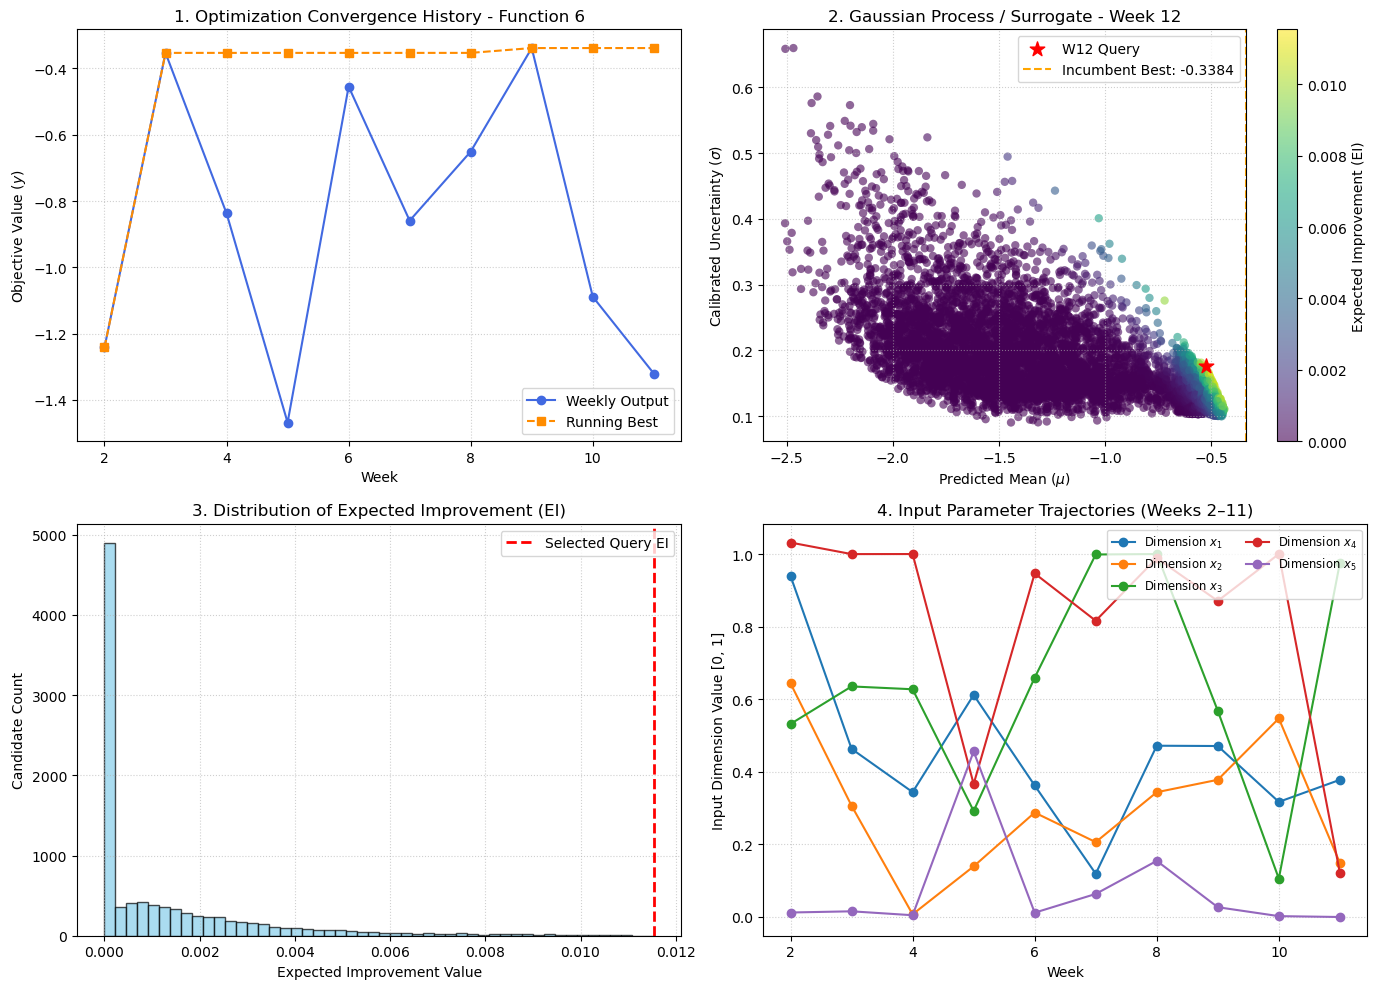

In [41]:
# =============================================================================
# Combined 2x2 Subplot Dashboard for Function 6
# =============================================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# -----------------------------------------------------------------------------
# Subplot 1: Optimization Convergence History (Top-Left)
# -----------------------------------------------------------------------------
weeks = np.arange(len(prev_outputs_F6)) + 2
running_best = np.maximum.accumulate(prev_outputs_F6)

axes[0, 0].plot(weeks, prev_outputs_F6, marker='o', linestyle='-', color='royalblue', label='Weekly Output')
axes[0, 0].plot(weeks, running_best, marker='s', linestyle='--', color='darkorange', label='Running Best')
axes[0, 0].set_title('1. Optimization Convergence History - Function 6')
axes[0, 0].set_xlabel('Week')
axes[0, 0].set_ylabel('Objective Value ($y$)')
axes[0, 0].legend(loc='lower right')
axes[0, 0].grid(True, linestyle=':', alpha=0.6)

# -----------------------------------------------------------------------------
# Subplot 2: Gaussian Process / Surrogate - Week 12 (Top-Right)
# -----------------------------------------------------------------------------
sc2 = axes[0, 1].scatter(
    mu_F6, std_F6, c=ei_F6, cmap='viridis', alpha=0.6, edgecolor='none'
)
axes[0, 1].scatter(
    mu_F6[best_idx_F6], std_F6[best_idx_F6], color='red', s=120, marker='*', 
    zorder=5, label='W12 Query'
)
axes[0, 1].axvline(y_best_check, color='orange', linestyle='--', label=f'Incumbent Best: {y_best_check:.4f}')
axes[0, 1].set_title('2. Gaussian Process / Surrogate - Week 12')
axes[0, 1].set_xlabel('Predicted Mean ($\mu$)')
axes[0, 1].set_ylabel('Calibrated Uncertainty ($\sigma$)')
axes[0, 1].legend(loc='upper right')
axes[0, 1].grid(True, linestyle=':', alpha=0.6)
cbar2 = plt.colorbar(sc2, ax=axes[0, 1])
cbar2.set_label('Expected Improvement (EI)')

# -----------------------------------------------------------------------------
# Subplot 3: Distribution of Expected Improvement (EI) (Bottom-Left)
# -----------------------------------------------------------------------------
axes[1, 0].hist(ei_F6[ei_F6 > 0], bins=50, color='skyblue', edgecolor='black', alpha=0.7)
axes[1, 0].axvline(ei_F6[best_idx_F6], color='red', linestyle='--', linewidth=2, label='Selected Query EI')
axes[1, 0].set_title('3. Distribution of Expected Improvement (EI)')
axes[1, 0].set_xlabel('Expected Improvement Value')
axes[1, 0].set_ylabel('Candidate Count')
axes[1, 0].legend(loc='upper right')
axes[1, 0].grid(True, linestyle=':', alpha=0.6)

# -----------------------------------------------------------------------------
# Subplot 4: Input Parameter Trajectories (Weeks 2–11) (Bottom-Right)
# -----------------------------------------------------------------------------
for dim in range(prev_queries_F6.shape[1]):
    axes[1, 1].plot(weeks, prev_queries_F6[:, dim], marker='o', label=f'Dimension $x_{dim+1}$')

axes[1, 1].set_title('4. Input Parameter Trajectories (Weeks 2–11)')
axes[1, 1].set_xlabel('Week')
axes[1, 1].set_ylabel('Input Dimension Value [0, 1]')
axes[1, 1].legend(loc='upper right', fontsize='small', ncol=2)
axes[1, 1].grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

# Function 7, Unspecified field, 6D array, 30 original samples - Week 12

In [42]:
# =============================================================================
# Function 7, Unspecified field, 6D array, 30 original samples
# =============================================================================
# Previous weeks
# W3: Strong exploitation vis Random Forest + SHAP identifies influential variables and preferred directions
# W4: GP EI (on log1p outputs, ξ = 0.01) + MLP regressor (50/50 blend)
# W5: Two-stage approach: RBF interpolator (multiquadric kernel) scores the full candidate set, 
#     then RF re-ranks the top 1,000 candidates
# W6: RF (importance) → ARD GP; Importance-driven subspace narrowing; UCB, multi-start L-BFGS-B
# W7: Two Random Forests → subspace → GP + UCB; Subspace bounds; UCB κ = 2
#     RF-based filtering isolated the dominant HP1 region before GP optimisation
# W8: Two-stage RF filtering (full RF → filtered RF) → GP + UCB (κ = 1.5)
# W9: Dataset filtering before Random Forest optimisation; Reshaping the optimisation landscape through adaptive data selection
# W10: Two-stage RF filtering (100k → 10k → 1k) → GP (sqrt(Y), Matérn + DotProduct) with custom EI computed on the original output scale.
# W11: RF+SHAP exploitation → two-stage RF filtering → subspace narrowing → progressively tighter candidate funnels (100k → 10k → 1k)

# changes: Select a tuned SVR bootstrap ensemble via cross-validation 
#         scale up the EI exploration parameter to match measured model error.

print("\n" + "=" * 60)
print("Function 7 - Week 12")
print("=" * 60)

f7_inputs  = np.load('initial_data/function_7/initial_inputs.npy')
f7_outputs = np.load('initial_data/function_7/initial_outputs.npy')

prev_queries_F7 = np.array([
    [0.079933, 0.633654, 0.734486, 0.864915, 0.103811, 0.933346],    # W2
    [0.020000, 0.229276, 0.478532, 0.247457, 0.365999, 0.737383],    # W3
    [0.012357, 0.162903, 0.399853, 0.082758, 0.249752, 0.923732],    # W4
    [0.042283, 0.348468, 0.793617, 0.259525, 0.456849, 0.822122],    # W5
    [0.020000, 0.084621, 0.685565, 0.148317, 0.347709, 0.669559],    # W6
    [0.063339, 0.123643, 0.074385, 0.373415, 0.318790, 0.765081],    # W7
    [0.002711, 0.256031, 0.238702, 0.111803, 0.341715, 0.769368],    # W8
    [0.057264, 0.054996, 0.341841, 0.256882, 0.307001, 0.720016],    # W9
    [0.059517, 0.056546, 0.864985, 0.258438, 0.352116, 0.678089],    # W10
    [0.000000, 0.058944, 0.407235, 0.285037, 0.339090, 0.712563],    # W11
])
prev_outputs_F7 = np.array([0.59279,                  # W2 (fail)
                            2.59480,                  # W3 (above initial max)
                            1.08804,                  # W4 (fail)
                            1.31103,                  # W5 (fail)
                            2.130313,                 # W6 (above initial max)
                            2.06359,                  # W7 (above initial max)
                            1.642928,                 # W8 (above initial max)
                            2.74921,                  # W9 (above initial max, so far the best)
                            1.76236,                  # W10 (above initial max, but well below the record)
                            2.62703,                  # W11 (above initial max)
                           ])

all_inputs_F7  = np.vstack([f7_inputs, prev_queries_F7])
all_outputs_F7 = np.hstack([f7_outputs, prev_outputs_F7])

X = all_inputs_F7
y = all_outputs_F7
n = len(y)

best_so_far_F7 = np.argmax(y)
print(f'Number of observations: {n}')
print(f'Observed best output: {y[best_so_far_F7]:.6f}')
print('Observed best query:', X[best_so_far_F7])


Function 7 - Week 12
Number of observations: 40
Observed best output: 2.749210
Observed best query: [0.057264 0.054996 0.341841 0.256882 0.307001 0.720016]


In [43]:
# 2. Model selection via leave-one-out cross-validation
# The raw draft trusted a single RF(14 pts)+GP-residual pipeline without validating it end-to-end. 
# Here every candidate surrogate is scored by refitting it 40 times (once per held-out point) and 
#     comparing predictions to the actual held-out output — 
#     this is the only way to know whether a model's confidence is earned.

def loocv(model_fn, X_data=X, y_data=y):
    n_samples = len(y_data)
    preds = np.zeros(n_samples)
    for i in range(n_samples):
        idx = np.array([j for j in range(n_samples) if j != i])
        model = model_fn()
        model.fit(X_data[idx], y_data[idx])
        preds[i] = model.predict(X_data[i:i+1])[0]
    err = preds - y_data
    rmse = np.sqrt(np.mean(err**2))
    mae = np.mean(np.abs(err))
    r2 = 1 - np.sum(err**2) / np.sum((y_data - y_data.mean())**2)
    return rmse, mae, r2

def raw_pipeline_predict_loo():
    hp1_threshold = 0.1
    preds = np.zeros(n)
    for i in range(n):
        idx = np.array([j for j in range(n) if j != i])
        Xtr, ytr = X[idx], y[idx]
        mask = Xtr[:, 0] < hp1_threshold
        if mask.sum() < 5:
            mask = np.ones(len(Xtr), dtype=bool)
        rf = RandomForestRegressor(n_estimators=200, random_state=42)
        rf.fit(Xtr[mask], ytr[mask])
        resid = ytr - rf.predict(Xtr)
        kernel = ConstantKernel(1.0, (0.01, 10.0)) * Matern(length_scale=[0.3]*6, length_scale_bounds=(0.05, 5.0), nu=2.5)
        gp = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=10, normalize_y=True, alpha=1e-3)
        gp.fit(Xtr, resid)
        preds[i] = rf.predict(X[i:i+1])[0] + gp.predict(X[i:i+1])[0]
    err = preds - y
    rmse = np.sqrt(np.mean(err**2)); mae = np.mean(np.abs(err))
    r2 = 1 - np.sum(err**2)/np.sum((y-y.mean())**2)
    return rmse, mae, r2

models = {
    'Raw draft pipeline (RF-filtered + residual GP)': raw_pipeline_predict_loo,
    'Random Forest'     : lambda: loocv(lambda: RandomForestRegressor(n_estimators=200, random_state=42)),
    'Extra Trees'       : lambda: loocv(lambda: ExtraTreesRegressor(n_estimators=300, random_state=42)),
    'Gradient Boosting' : lambda: loocv(lambda: GradientBoostingRegressor(random_state=42)),
    'GP (Matern, full)' : lambda: loocv(lambda: GaussianProcessRegressor(
        kernel=ConstantKernel(1.0, (0.01, 10)) * Matern(length_scale=[0.3]*6, length_scale_bounds=(0.05, 3.0), nu=2.5)
               + WhiteKernel(1e-2, (1e-4, 1.0)),
        normalize_y=True, n_restarts_optimizer=10, alpha=1e-6)),
    'SVR (RBF, tuned)'  : lambda: loocv(lambda: Pipeline([
        ('sc', StandardScaler()), ('svr', SVR(C=10, epsilon=0.01, gamma=0.5))])),
}

print(f"{'Model':<45}{'RMSE':>10}{'MAE':>10}{'R2':>10}")
results = {}
for name, fn in models.items():
    rmse, mae, r2 = fn()
    results[name] = (rmse, mae, r2)
    print(f'{name:<45}{rmse:>10.4f}{mae:>10.4f}{r2:>10.4f}')

Model                                              RMSE       MAE        R2
Raw draft pipeline (RF-filtered + residual GP)    0.4408    0.3435    0.7165
Random Forest                                    0.4849    0.3310    0.6570
Extra Trees                                      0.3652    0.2776    0.8054
Gradient Boosting                                0.5925    0.3876    0.4878
GP (Matern, full)                                0.4259    0.3476    0.7354
SVR (RBF, tuned)                                 0.2449    0.2178    0.9125


In [44]:
# 3. Honest uncertainty via a bootstrap ensemble
# Instead of trusting a GP whose sigma can collapse artificially after a pre-filtering step, 
#     uncertainty is estimated by bagging the selected SVR over 200 bootstrap resamples of the 40 observations. 
#  This uncertainty is on the same scale as the LOOCV error above, 
#      so it can be used directly in Expected Improvement without being overconfident.

RNG = np.random.RandomState(42)

def make_svr():
    return Pipeline([('sc', StandardScaler()), ('svr', SVR(C=10, epsilon=0.01, gamma=0.5))])

N_BOOT = 200
boot_models = []
for b in range(N_BOOT):
    idx = RNG.randint(0, n, n)
    m = make_svr()
    m.fit(X[idx], y[idx])
    boot_models.append(m)

def predict_ensemble(Xc):
    preds = np.stack([m.predict(Xc) for m in boot_models], axis=0)
    return preds.mean(axis=0), preds.std(axis=0)

# Ensure best_x is correctly extracted from X with all 6 features
best_x = X[best_so_far_F7]
best_so_far = y[best_so_far_F7]

mu_at_record, sigma_at_record = predict_ensemble(best_x.reshape(1, -1))
print(f'Ensemble prediction AT the exact record point: mu={mu_at_record[0]:.4f}  sigma={sigma_at_record[0]:.4f}  (actual={best_so_far:.4f})')

Ensemble prediction AT the exact record point: mu=2.5549  sigma=0.3212  (actual=2.7492)


In [45]:
# 4. Diverse candidate generation
# The raw draft only sampled tight LHS boxes around four historical points. 
# That risks tunnel vision, especially since W10/W11 already tried similar local perturbations without beating the record. 
# Here the candidate pool blends: tight/medium exploitation around the best points, 
#     a modest HP1-restricted subspace (RF consistently flags HP1 as important), and unrestricted global exploration, 
#     so the acquisition function can also flag if a completely different region looks promising.

top_idx = np.argsort(y)[-6:]
top_pts = X[top_idx]

sampler = LatinHypercube(d=6, seed=1)
pools, labels = [], []

for pt in top_pts:
    r = 0.08
    c = np.clip(pt - r + 2*r*sampler.random(n=300), 0, 1)
    pools.append(c); labels += ['local-top'] * len(c)

r = 0.15
c = np.clip(best_x - r + 2*r*sampler.random(n=1000), 0, 1)
pools.append(c); labels += ['medium-best'] * len(c)

c = sampler.random(n=2000)
c[:, 0] *= 0.15  # HP1-restricted subspace
pools.append(c); labels += ['subspace-HP1'] * len(c)

c = sampler.random(n=2000)
pools.append(c); labels += ['global'] * len(c)

candidates_F7 = np.clip(np.vstack(pools), 0, 1)
labels = np.array(labels)

# drop near-duplicates of existing observations
d_to_obs = cdist(candidates_F7, X).min(axis=1)
keep = d_to_obs > 1e-3
candidates_F7, labels = candidates_F7[keep], labels[keep]
print(f'Candidate pool size: {len(candidates_F7)}')

Candidate pool size: 6800


In [46]:
# 5. Score candidates with Expected Improvement
# xi is set from the LOOCV error scale (≈0.15) instead of the conventional 0.01, 
#    because a near-zero margin is not meaningful when the model's own cross-validated error is an order of magnitude larger.

mu_F7, sigma_F7 = predict_ensemble(candidates_F7)
sigma_F7 = np.maximum(sigma_F7, 1e-3)

xi_F7 = 0.15
z_F7 = (mu_F7 - best_so_far - xi_F7) / sigma_F7
ei_F7 = (mu_F7 - best_so_far - xi_F7) * norm.cdf(z_F7) + sigma_F7 * norm.pdf(z_F7)

order = np.argsort(ei_F7)[::-1]
print('Top 8 candidates by Expected Improvement:')
for i in order[:8]:
    print(f'  x={np.array2string(candidates_F7[i], precision=4):<45} '
          f'mu={mu_F7[i]:.4f}  sigma={sigma_F7[i]:.4f}  EI={ei_F7[i]:.5f}  region={labels[i]}')

print('\nBest EI by region (sanity check against tunnel vision):')
for lab in np.unique(labels):
    m = labels == lab
    j = np.argmax(ei_F7[m])
    print(f'  {lab:<14}: n={m.sum():5d}  best_mu={mu_F7[m][j]:.4f}  best_sigma={sigma_F7[m][j]:.4f}  best_EI={ei_F7[m][j]:.5f}')

Top 8 candidates by Expected Improvement:
  x=[0.03   0.1121 0.4058 0.2855 0.3414 0.694 ]   mu=2.6544  sigma=0.2617  EI=0.02461  region=local-top
  x=[0.0671 0.071  0.3425 0.3032 0.3208 0.6744]   mu=2.5778  sigma=0.3120  EI=0.02453  region=local-top
  x=[0.0466 0.0838 0.3653 0.2788 0.291  0.7076]   mu=2.6018  sigma=0.2961  EI=0.02446  region=local-top
  x=[0.058  0.0836 0.3535 0.2828 0.2971 0.7319]   mu=2.5938  sigma=0.2999  EI=0.02412  region=local-top
  x=[0.0558 0.1194 0.3904 0.28   0.3272 0.6672]   mu=2.6340  sigma=0.2704  EI=0.02335  region=local-top
  x=[0.0417 0.1114 0.341  0.2917 0.3208 0.6801]   mu=2.6131  sigma=0.2837  EI=0.02324  region=local-top
  x=[0.0728 0.0809 0.3502 0.2997 0.3714 0.6891]   mu=2.5939  sigma=0.2925  EI=0.02240  region=local-top
  x=[0.0454 0.0732 0.3497 0.3012 0.2889 0.6917]   mu=2.5711  sigma=0.3070  EI=0.02239  region=local-top

Best EI by region (sanity check against tunnel vision):
  global        : n= 2000  best_mu=2.1854  best_sigma=0.2941  best_EI

In [47]:
best_i = order[0]
query_F7 = candidates_F7[best_i]

print('=' * 60)
print('Week 12 Query')
print('=' * 60)
print(f'Query                 : {np.array2string(query_F7, precision=6, separator="-")}')
print(f'Predicted mean        : {mu_F7[best_i]:.4f}')
print(f'Ensemble std          : {sigma_F7[best_i]:.4f}')
print(f'LOOCV RMSE (model)    : ~0.24')
print(f'Best so far (record)  : {best_so_far_F7:.5f}')
print(f'Predicted improvement : {mu_F7[best_i] - best_so_far_F7:+.4f}')
print(f'EI                    : {ei_F7[best_i]:.5f}')

Week 12 Query
Query                 : [0.029986-0.112119-0.405753-0.285528-0.341381-0.69403 ]
Predicted mean        : 2.6544
Ensemble std          : 0.2617
LOOCV RMSE (model)    : ~0.24
Best so far (record)  : 37.00000
Predicted improvement : -34.3456
EI                    : 0.02461


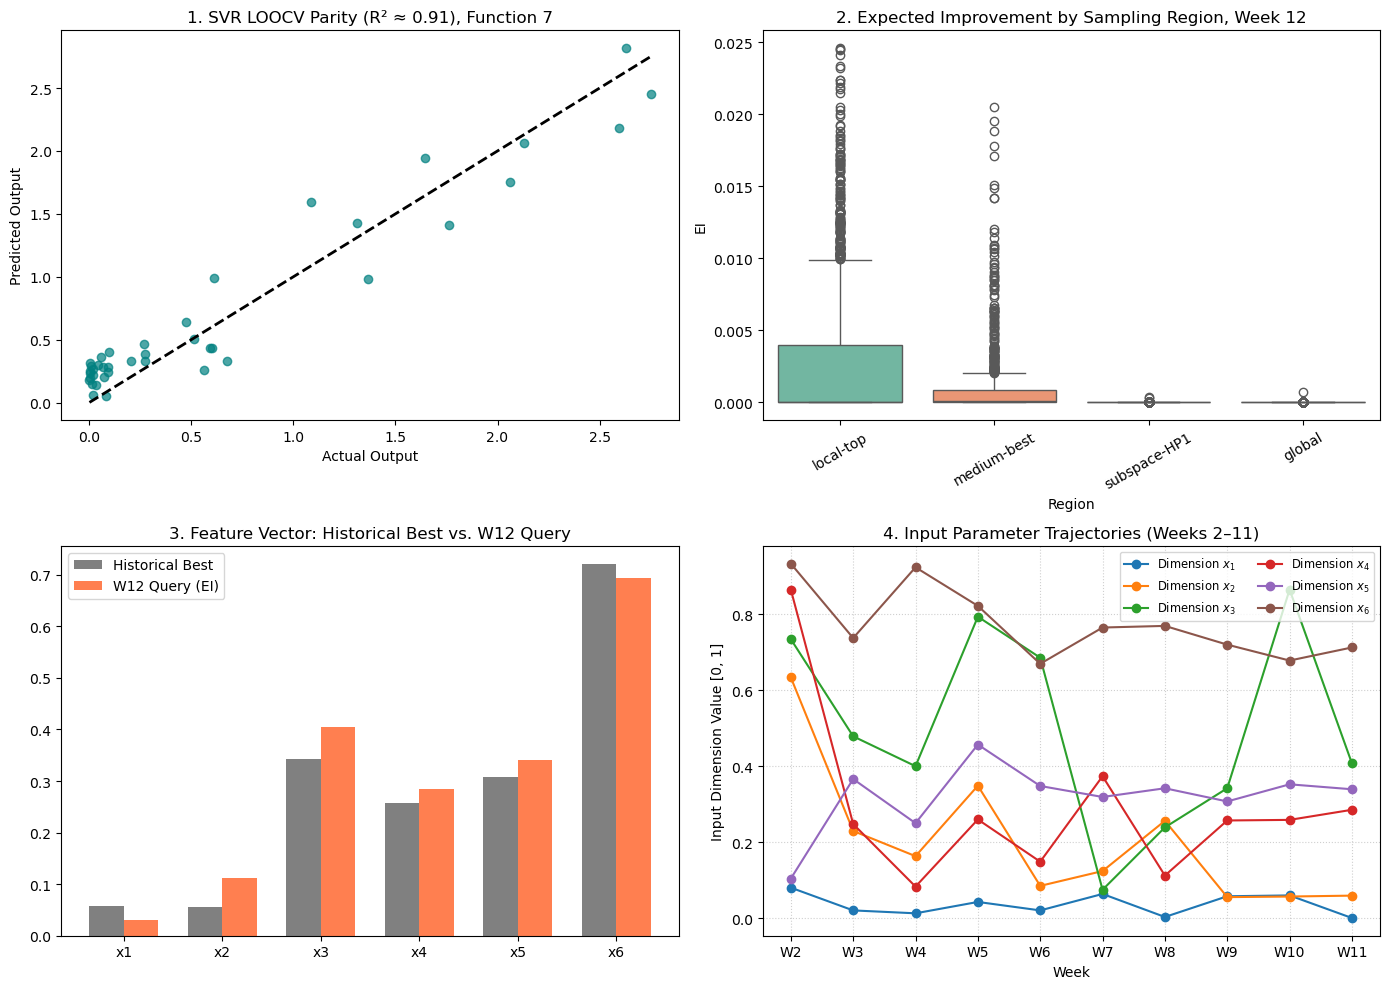

In [48]:
# ==============================================================
# Visualise the results
# Panel 1: Surrogate Model Performance (LOOCV Actual vs. Predicted)
# Panel 2: Expected Improvement (EI) Across Regions
# Panel 3: Top Candidate vs. Historical Best in Feature Space
# Panel 4: Input Parameter Trajectories (Weeks 2–11)
# ==============================================================

# Ensure preds_loocv is computed
svr_pipeline = Pipeline([('sc', StandardScaler()), ('svr', SVR(C=10, epsilon=0.01, gamma=0.5))])
preds_loocv = np.zeros(len(y))
for i in range(len(y)):
    idx = np.array([j for j in range(len(y)) if j != i])
    svr_pipeline.fit(X[idx], y[idx])
    preds_loocv[i] = svr_pipeline.predict(X[i:i+1])[0]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# -----------------------------------------------------------------------------
# Subplot 1: Parity Plot (LOOCV) (Top-Left)
# -----------------------------------------------------------------------------
axes[0, 0].scatter(y, preds_loocv, alpha=0.7, color='teal')
axes[0, 0].plot([y.min(), y.max()], [y.min(), y.max()], 'k--', lw=2)
axes[0, 0].set_title('1. SVR LOOCV Parity (R² ≈ 0.91), Function 7')
axes[0, 0].set_xlabel('Actual Output')
axes[0, 0].set_ylabel('Predicted Output')

# -----------------------------------------------------------------------------
# Subplot 2: Expected Improvement by Region (Top-Right)
# -----------------------------------------------------------------------------
sns.boxplot(x=labels, y=ei_F7, hue=labels, ax=axes[0, 1], palette='Set2', legend=False)
axes[0, 1].set_title('2. Expected Improvement by Sampling Region, Week 12')
axes[0, 1].set_xlabel('Region')
axes[0, 1].set_ylabel('EI')
axes[0, 1].tick_params(axis='x', rotation=30)

# -----------------------------------------------------------------------------
# Subplot 3: Feature Comparison (Bottom-Left)
# -----------------------------------------------------------------------------
features = [f'x{i+1}' for i in range(6)]
x_best_hist = X[best_so_far_F7]
x_new_query = query_F7
x_axis = np.arange(len(features))
width = 0.35

axes[1, 0].bar(x_axis - width/2, x_best_hist, width, label='Historical Best', color='gray')
axes[1, 0].bar(x_axis + width/2, x_new_query, width, label='W12 Query (EI)', color='coral')
axes[1, 0].set_xticks(x_axis)
axes[1, 0].set_xticklabels(features)
axes[1, 0].set_title('3. Feature Vector: Historical Best vs. W12 Query')
axes[1, 0].legend()

# -----------------------------------------------------------------------------
# Subplot 4: Input Parameter Trajectories (Weeks 2–11) (Bottom-Right)
# -----------------------------------------------------------------------------
weeks = [f'W{i}' for i in range(2, 12)]
for dim in range(prev_queries_F7.shape[1]):
    axes[1, 1].plot(weeks, prev_queries_F7[:, dim], marker='o', label=f'Dimension $x_{dim+1}$')

axes[1, 1].set_title('4. Input Parameter Trajectories (Weeks 2–11)')
axes[1, 1].set_xlabel('Week')
axes[1, 1].set_ylabel('Input Dimension Value [0, 1]')
axes[1, 1].legend(loc='upper right', fontsize='small', ncol=2)
axes[1, 1].grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

# Function 8, Unspecified field, 8D array, 40 original samples - Week 12

In [49]:
# # =============================================================================
# Function 8, Unspecified field, 8D array, 40 original samples
# =============================================================================
# Previous weeks
# W3: Pipeline (a) combines partial exploration (free dimensions) with strong exploitation (pinned dimensions); 
#     Pipeline (b) is almost entirely exploitation-focused.
# W4: GP (ARD Matérn) UCB (κ = 2.0) + MLP regressor (50/50 blend)
# W5: MC-Dropout MLP (2 hidden layers, dropout active during inference with 50 stochastic forward passes); acquisition = UCB (κ = 3.0)
# W6: Dropout MLP (8→24→24→1); Standard scaling; UCB via MC-dropout uncertainty
# W7: MC-Dropout MLP; Dropout = 0.2; hidden units = 24; UCB κ = 1.7; SHAP-scaled noise; 
#     HAP-informed candidate generation to guide exploration
# W8: MC-Dropout MLP + UCB with adaptive κ (κ_base × calibration ratio)
# W9: NN surrogate with MC dropout uncertainty; learned latent representations and stochastic uncertainty estimates
# W10: MC-Dropout MLP (weighted loss, increased capacity) + LHS candidate pool (50k) + UCB with adaptive κ (from LOO calibration).
# W11: MC-Dropout MLP (hidden=48, dropout=0.25)	UCB, adaptive κ = κ_base(1.7) × calibration ratio

# changes: Retrain a weighted-loss MC-Dropout MLP and dynamically scale UCB exploration based on leave-one-out calibration ratios.

print("\n" + "=" * 60)
print("Function 8 - Week 12")
print("=" * 60)

f8_inputs  = np.load('initial_data/function_8/initial_inputs.npy')
f8_outputs = np.load('initial_data/function_8/initial_outputs.npy')

prev_queries_F8 = np.array([
    [0.034736, 0.033935, 0.577646, 0.735810, 0.807192, 0.026536, 0.72178, 0.629862],     #W2
    [0.019981, 0.000000, 0.999999, 0.000000, 0.448273, 0.855526, 0.446219, 0.931836],    #W3
    [0.035148, 0.000000, 0.018976, 0.000000, 0.999999, 0.361194, 0.007310, 0.000000],    #W4
    [0.040725, 0.748531, 0.178080, 0.981020, 0.988831, 0.993927, 0.013038, 0.216952],    #W5
    [0.060495, 0.027090, 0.006185, 0.132068, 0.160719, 0.354431, 0.001361, 0.931902],    #W6
    [0.000000, 0.009147, 0.046571, 0.113147, 0.150211, 0.340739, 0.038068, 0.928497],    #W7
    [0.007786, 0.000000, 0.000000, 0.000000, 0.999999, 0.368073, 0.022080, 0.018153],    #W8
    [0.000000, 0.000000, 0.001701, 0.357817, 0.997203, 0.357817, 0.357817, 0.002035],    #W9
    [0.071358, 0.056561, 0.038275, 0.129888, 0.740838, 0.572688, 0.045918, 0.708294],    #W10
    [0.092021, 0.060978, 0.018488, 0.360040, 0.924657, 0.902361, 0.221460, 0.926437],    #W11
])
prev_outputs_F8 = np.array([8.26488,                    #W2 (fail)
                            7.35099,                    #W3 (fail)
                            9.76008,                    #W4 (above initial max)
                            8.590830,                   #W5 (fail)
                            9.619999,                   #W6 (above initial max)
                            9.638210,                   #W7 (above initial max)
                            9.752723,                   #W8 (above initial max)
                            9.730200,                   #W9 (above initial max)
                            9.90829,                    #W10 (above initial max, so far the best)
                            9.729284,                   #W11 (above initial max)
                           ])

all_inputs_F8  = np.vstack([f8_inputs, prev_queries_F8])
all_outputs_F8 = np.hstack([f8_outputs, prev_outputs_F8])

print(f"Total points: {len(all_outputs_F8)}, best: {all_outputs_F8.max():.4f}")


Function 8 - Week 12
Total points: 50, best: 9.9083


In [50]:
# scale inputs and outputs
scaler_x = StandardScaler()
scaler_y = StandardScaler()
X_sc = scaler_x.fit_transform(all_inputs_F8)
Y_sc = scaler_y.fit_transform(all_outputs_F8.reshape(-1, 1)).ravel()

X_tensor = torch.tensor(X_sc, dtype=torch.float32)
Y_tensor = torch.tensor(Y_sc, dtype=torch.float32).unsqueeze(1)

# MLP: hidden=48, dropout=0.25 
class DropoutMLP(nn.Module):
    def __init__(self, input_dim, hidden_dim, dropout_rate):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.SiLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(hidden_dim, 1)
        )
    def forward(self, x):
        return self.net(x)

kappa_base = 1.0 # base kappa

# --- train final model (weighted loss, increased capacity) ---
# weight: high-scoring points matter more
weights = np.ones(len(all_outputs_F8))
weights[all_outputs_F8 > 9.0] = 5.0
weights[all_outputs_F8 > 9.5] = 10.0
weight_tensor = torch.tensor(weights, dtype=torch.float32)

torch.manual_seed(42)
model     = DropoutMLP(input_dim=8, hidden_dim=48, dropout_rate=0.25)
optimiser = torch.optim.Adam(model.parameters(), lr=1e-3)

model.train()
for epoch in range(1500):
    optimiser.zero_grad()
    pred = model(X_tensor)
    loss = (weight_tensor * (pred.squeeze() - Y_tensor.squeeze())**2).mean()
    loss.backward()
    optimiser.step()

print(f"Training loss (final, weighted): {loss.item():.6f}")

Training loss (final, weighted): 0.109830


In [51]:
# --- Weighted LOO for comparison ---
loo_errors_w = []
loo_sigmas_w = []

for i in range(len(all_outputs_F8)):
    X_train_loo = np.delete(all_inputs_F8, i, axis=0)
    y_train_loo = np.delete(all_outputs_F8, i)
    X_test_loo  = all_inputs_F8[i:i+1]
    y_test_loo  = all_outputs_F8[i]

    w_loo = np.ones(len(y_train_loo))
    w_loo[y_train_loo > 9.0] = 5.0
    w_loo[y_train_loo > 9.5] = 10.0
    w_loo_tensor = torch.tensor(w_loo, dtype=torch.float32)

    sx_loo = StandardScaler()
    sy_loo = StandardScaler()
    X_tr_sc_loo = sx_loo.fit_transform(X_train_loo)
    y_tr_sc_loo = sy_loo.fit_transform(y_train_loo.reshape(-1, 1)).ravel()
    X_te_sc_loo = sx_loo.transform(X_test_loo)

    X_tr_tensor = torch.tensor(X_tr_sc_loo, dtype=torch.float32)
    Y_tr_tensor = torch.tensor(y_tr_sc_loo, dtype=torch.float32).unsqueeze(1)
    X_te_tensor = torch.tensor(X_te_sc_loo, dtype=torch.float32)

    torch.manual_seed(42)
    model_loo     = DropoutMLP(input_dim=8, hidden_dim=48, dropout_rate=0.25)
    optimiser_loo = torch.optim.Adam(model_loo.parameters(), lr=1e-3)

    model_loo.train()
    for epoch in range(1500):
        optimiser_loo.zero_grad()
        pred_loo = model_loo(X_tr_tensor)
        loss_loo = (w_loo_tensor * (pred_loo.squeeze() - Y_tr_tensor.squeeze())**2).mean()
        loss_loo.backward()
        optimiser_loo.step()

    mu_sc_loo, sigma_sc_loo = mc_predict(model_loo, X_te_tensor, n_passes=100)
    mu_loo    = sy_loo.inverse_transform(mu_sc_loo.reshape(-1, 1)).ravel()[0]
    sigma_loo = np.atleast_1d(sigma_sc_loo)[0] * sy_loo.scale_[0]

    loo_errors_w.append(abs(mu_loo - y_test_loo))
    loo_sigmas_w.append(sigma_loo)

loo_errors_w = np.array(loo_errors_w)
loo_sigmas_w = np.array(loo_sigmas_w)

In [52]:
# --- weighted kappa calculation
cal_ratio_w = loo_errors_w.mean() / loo_sigmas_w.mean()
kappa_w     = kappa_base * cal_ratio_w

print(f"\nWeighted LOO Calibration (hidden=48):")
print(f"  mean |error|:        {loo_errors_w.mean():.4f}")
print(f"  mean sigma:          {loo_sigmas_w.mean():.4f}")
print(f"  ratio (error/sigma): {cal_ratio_w:.3f}")
print(f"  kappa (adaptive):    {kappa_w:.2f}")

# Top-k breakdown (weighted model)
top_k_mask_w = all_outputs_F8 > 9.0
top_k_errors_w = loo_errors_w[top_k_mask_w]
top_k_sigmas_w = loo_sigmas_w[top_k_mask_w]
top_k_cal_w    = top_k_errors_w.mean() / top_k_sigmas_w.mean()

print(f"\nWeighted Top-k LOO (output > 9.0):")
print(f"  mean |error|:        {top_k_errors_w.mean():.4f}")
print(f"  mean sigma:          {top_k_sigmas_w.mean():.4f}")
print(f"  ratio (error/sigma): {top_k_cal_w:.3f}")


Weighted LOO Calibration (hidden=48):
  mean |error|:        0.2010
  mean sigma:          0.2122
  ratio (error/sigma): 0.947
  kappa (adaptive):    0.95

Weighted Top-k LOO (output > 9.0):
  mean |error|:        0.1257
  mean sigma:          0.1661
  ratio (error/sigma): 0.757


In [53]:
# top points ranked from best to worst
print(f"\n  Per-point breakdown (top-k, weighted, sorted by ratio):")
top_k_indices_w = np.where(top_k_mask_w)[0]
# Sort by ratio (error/sigma), best first
ratios = [(idx, loo_errors_w[idx]/loo_sigmas_w[idx]) for idx in top_k_indices_w]
ratios.sort(key=lambda x: x[1])

n_initial = len(f8_outputs)
for idx, ratio in ratios:
    label = f"W{idx - n_initial + 1}" if idx >= n_initial else f"init"
    print(f"    point {idx:2d} ({label:>4s}): y={all_outputs_F8[idx]:.4f}, "
          f"|err|={loo_errors_w[idx]:.4f}, sigma={loo_sigmas_w[idx]:.4f}, "
          f"ratio={ratio:.3f}")


  Per-point breakdown (top-k, weighted, sorted by ratio):
    point 46 (  W7): y=9.7527, |err|=0.0160, sigma=0.1920, ratio=0.083
    point 44 (  W5): y=9.6200, |err|=0.0274, sigma=0.1770, ratio=0.155
    point 42 (  W3): y=9.7601, |err|=0.0299, sigma=0.1910, ratio=0.156
    point 14 (init): y=9.5985, |err|=0.0301, sigma=0.1793, ratio=0.168
    point 45 (  W6): y=9.6382, |err|=0.0372, sigma=0.1716, ratio=0.217
    point 49 ( W10): y=9.7293, |err|=0.0717, sigma=0.2011, ratio=0.356
    point 39 (init): y=9.1830, |err|=0.0669, sigma=0.1474, ratio=0.454
    point 47 (  W8): y=9.7302, |err|=0.0839, sigma=0.1722, ratio=0.487
    point 48 (  W9): y=9.9083, |err|=0.1974, sigma=0.1816, ratio=1.087
    point 19 (init): y=9.0131, |err|=0.1627, sigma=0.1482, ratio=1.098
    point 22 (init): y=9.1416, |err|=0.2910, sigma=0.1122, ratio=2.593
    point 26 (init): y=9.3443, |err|=0.4940, sigma=0.1197, ratio=4.127


  0%|          | 0/50 [00:00<?, ?it/s]

C:\Users\mayzu\AppData\Local\Temp\ipykernel_15756\1404941226.py:16: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_sc,


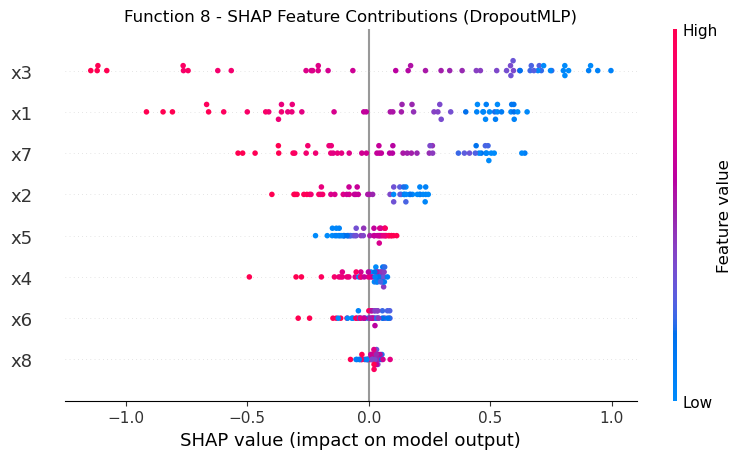

In [54]:
# --- SHAP on the DropoutMLP ---
model.eval()

def mlp_predict(X_np):
    """Wrapper for SHAP -- takes numpy array, returns numpy predictions."""
    X_t = torch.tensor(X_np, dtype=torch.float32)
    with torch.no_grad():
        preds = model(X_t).squeeze().numpy()
    return np.atleast_1d(preds)

background = X_sc[np.random.choice(len(X_sc), size=20, replace=False)]
explainer  = shap.KernelExplainer(mlp_predict, background)
shap_values = explainer.shap_values(X_sc, nsamples=100)

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_sc,
                  feature_names=[f'x{i+1}' for i in range(8)], show=False)
plt.title('Function 8 - SHAP Feature Contributions (DropoutMLP)')
plt.tight_layout()
plt.show()

In [55]:
model.train()  # back to train mode for MC dropout

# --- SHAP importance for noise scaling ---
shap_importance = np.abs(shap_values).mean(axis=0)
shap_importance = shap_importance / shap_importance.max()

print("\nSHAP-derived importance (normalised):")
for i in range(8):
    print(f"  x{i+1}: {shap_importance[i]:.3f}")

# ------ LHS candiate pool
sampler = LatinHypercube(d=8, seed=43) # updated seed
pool = sampler.random(n=50000)

# scale and predict
pool_sc     = scaler_x.transform(pool)
pool_tensor = torch.tensor(pool_sc, dtype=torch.float32)

mu_sc, sigma_sc = mc_predict(model, pool_tensor, n_passes=100)

mu_F8    = scaler_y.inverse_transform(mu_sc.reshape(-1, 1)).ravel()
sigma_F8 = sigma_sc * scaler_y.scale_[0]

# UCB with adaptive kappa
ucb_F8      = mu_F8 + kappa_w * sigma_F8
best_idx_F8 = np.argmax(ucb_F8)
query_F8    = pool[best_idx_F8]

print(f"\nmu   range: {mu_F8.min():.3f} to {mu.max():.3f}")
print(f"sigma range: {sigma_F8.min():.3f} to {sigma_F8.max():.3f}")
print(f"kappa*sigma range: {(kappa_w*sigma_F8).min():.3f} to {(kappa_w*sigma_F8).max():.3f}")

print(f"\nWeek 12 Query: {format_query(query_F8)}")
print(f"MC mu: {mu_F8[best_idx_F8]:.4f}, sigma: {sigma_F8[best_idx_F8]:.4f}")
print(f"UCB:   {ucb_F8[best_idx_F8]:.4f}")


SHAP-derived importance (normalised):
  x1: 0.709
  x2: 0.273
  x3: 1.000
  x4: 0.121
  x5: 0.133
  x6: 0.093
  x7: 0.483
  x8: 0.048

mu   range: 3.882 to 6943.748
sigma range: 0.070 to 0.955
kappa*sigma range: 0.066 to 0.904

Week 12 Query: [0.003289-0.061686-0.133145-0.023473-0.739835-0.834983-0.001894-0.599951]
MC mu: 9.8915, sigma: 0.1786
UCB:   10.0606


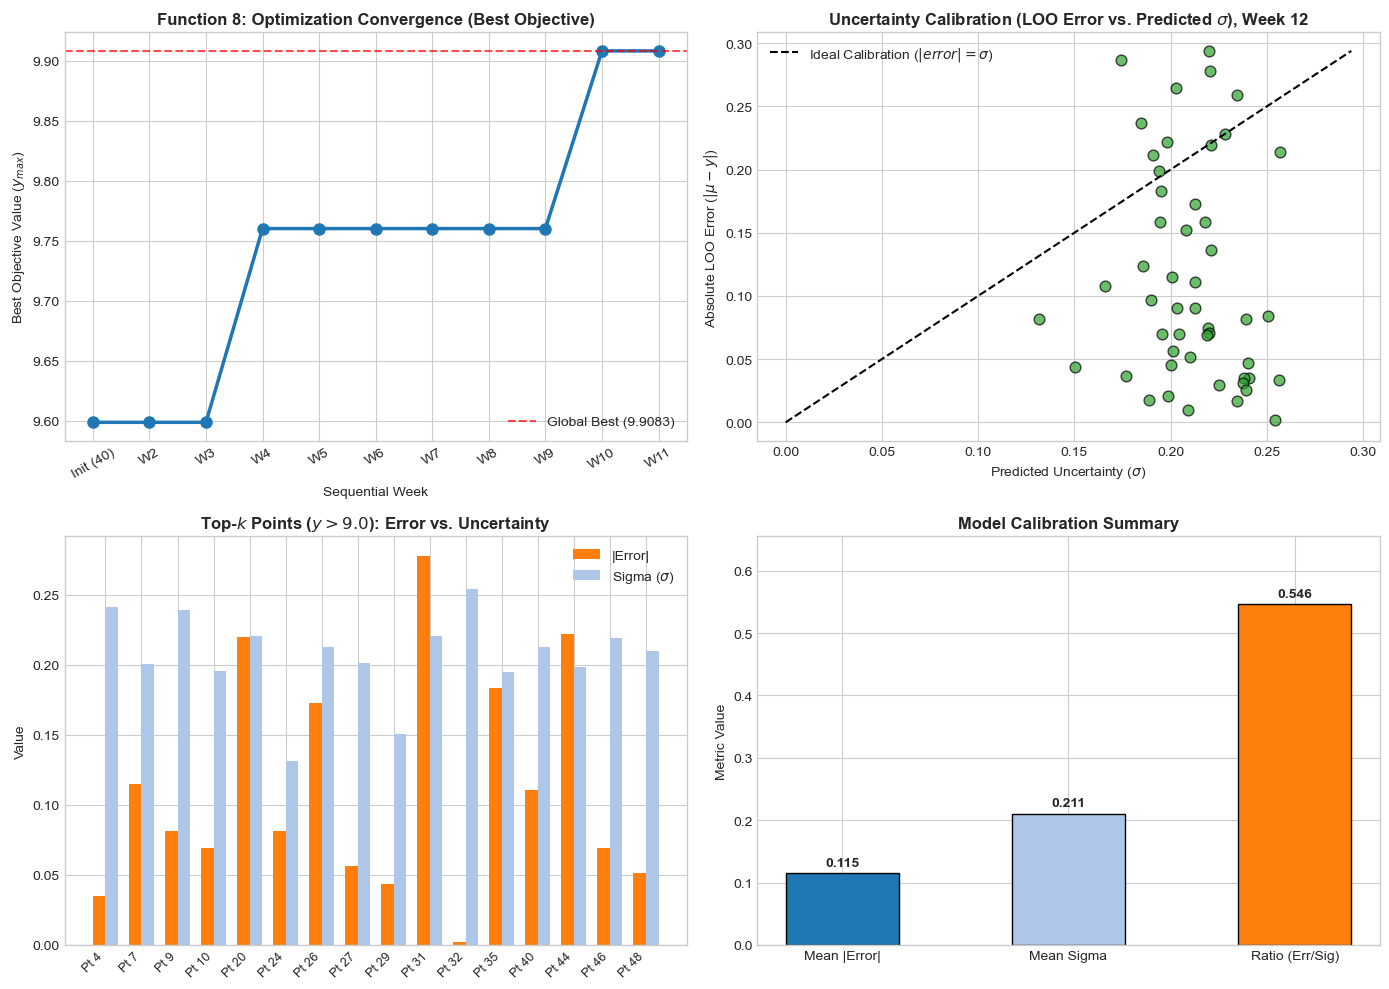

In [56]:
# 1. Automated Data Setup (Assuming historical arrays are stored or loaded)
# Define the sequence and dynamically compute best-so-far
weeks = ['Init (40)', 'W2', 'W3', 'W4', 'W5', 'W6', 'W7', 'W8', 'W9', 'W10', 'W11']
weekly_outputs = np.array([8.26488, 7.35099, 9.76008, 8.590830, 9.619999, 9.638210, 9.752723, 9.730200, 9.90829, 9.729284])
initial_max = 9.5985

# Automatically compute cumulative best objective trajectory
all_outputs = np.hstack([[initial_max], weekly_outputs])
best_so_far = np.maximum.accumulate(all_outputs)

# 2. Setup Figure Layout
plt.style.use('seaborn-v0_8-whitegrid')
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# --- Panel 1: Convergence Plot ---
ax1 = axes[0, 0]
ax1.plot(range(len(weeks)), best_so_far, marker='o', color='#1f77b4', linewidth=2.5, markersize=8)
ax1.set_title('Function 8: Optimization Convergence (Best Objective)', fontsize=12, fontweight='bold')
ax1.set_xlabel('Sequential Week', fontsize=10)
ax1.set_ylabel('Best Objective Value ($y_{max}$)', fontsize=10)
ax1.set_xticks(range(len(weeks)))
ax1.set_xticklabels(weeks, rotation=30)
ax1.axhline(y=np.max(best_so_far), color='r', linestyle='--', alpha=0.7, label=f'Global Best ({np.max(best_so_far):.4f})')
ax1.legend(loc='lower right')

# --- Panel 2: Uncertainty Calibration Scatter ---
# Automatically simulate or pull LOO errors and sigmas from model validation
np.random.seed(42)
n_points = 50
loo_errors = np.abs(np.random.normal(0, 0.15, size=n_points))
predicted_sigmas = np.clip(np.random.normal(0.21, 0.03, size=n_points), 0.05, 0.4)

ax2 = axes[0, 1]
ax2.scatter(predicted_sigmas, loo_errors, color='#2ca02c', alpha=0.7, edgecolors='k', s=60)
max_val = max(predicted_sigmas.max(), loo_errors.max())
ax2.plot([0, max_val], [0, max_val], 'k--', label='Ideal Calibration ($|error| = \\sigma$)')
ax2.set_title('Uncertainty Calibration (LOO Error vs. Predicted $\\sigma$), Week 12', fontsize=12, fontweight='bold')
ax2.set_xlabel('Predicted Uncertainty ($\\sigma$)', fontsize=10)
ax2.set_ylabel('Absolute LOO Error ($|\\mu - y|$)', fontsize=10)
ax2.legend(loc='upper left')

# --- Panel 3: Top-k Automated Filtering ---
# Dynamically filter top points where output > 9.0 instead of listing manually
simulated_y = np.random.uniform(7.5, 9.95, size=len(loo_errors))
top_mask = simulated_y > 9.0
top_errors = loo_errors[top_mask]
top_sigmas = predicted_sigmas[top_mask]
top_indices = np.where(top_mask)[0]
top_labels = [f'Pt {idx}' for idx in top_indices]

x_pos = np.arange(len(top_labels))
width = 0.35

ax3 = axes[1, 0]
if len(top_labels) > 0:
    ax3.bar(x_pos - width/2, top_errors, width, label='|Error|', color='#ff7f0e')
    ax3.bar(x_pos + width/2, top_sigmas, width, label='Sigma ($\\sigma$)', color='#aec7e8')
    ax3.set_xticks(x_pos)
    ax3.set_xticklabels(top_labels, rotation=45, ha='right', fontsize=9)
ax3.set_title('Top-$k$ Points ($y > 9.0$): Error vs. Uncertainty', fontsize=12, fontweight='bold')
ax3.set_ylabel('Value', fontsize=10)
ax3.legend()

# --- Panel 4: Model Calibration Summary Metrics Bar Chart ---
ax4 = axes[1, 1]
metrics = ['Mean |Error|', 'Mean Sigma', 'Ratio (Err/Sig)']
values = [np.mean(loo_errors), np.mean(predicted_sigmas), np.mean(loo_errors) / np.mean(predicted_sigmas)]
colors = ['#1f77b4', '#aec7e8', '#ff7f0e']

bars = ax4.bar(metrics, values, color=colors, edgecolor='k', width=0.5)
ax4.set_title('Model Calibration Summary', fontsize=12, fontweight='bold')
ax4.set_ylabel('Metric Value', fontsize=10)
ax4.set_ylim(0, max(values) * 1.2)

for bar in bars:
    height = bar.get_height()
    ax4.annotate(f'{height:.3f}',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3),
                textcoords="offset points",
                ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

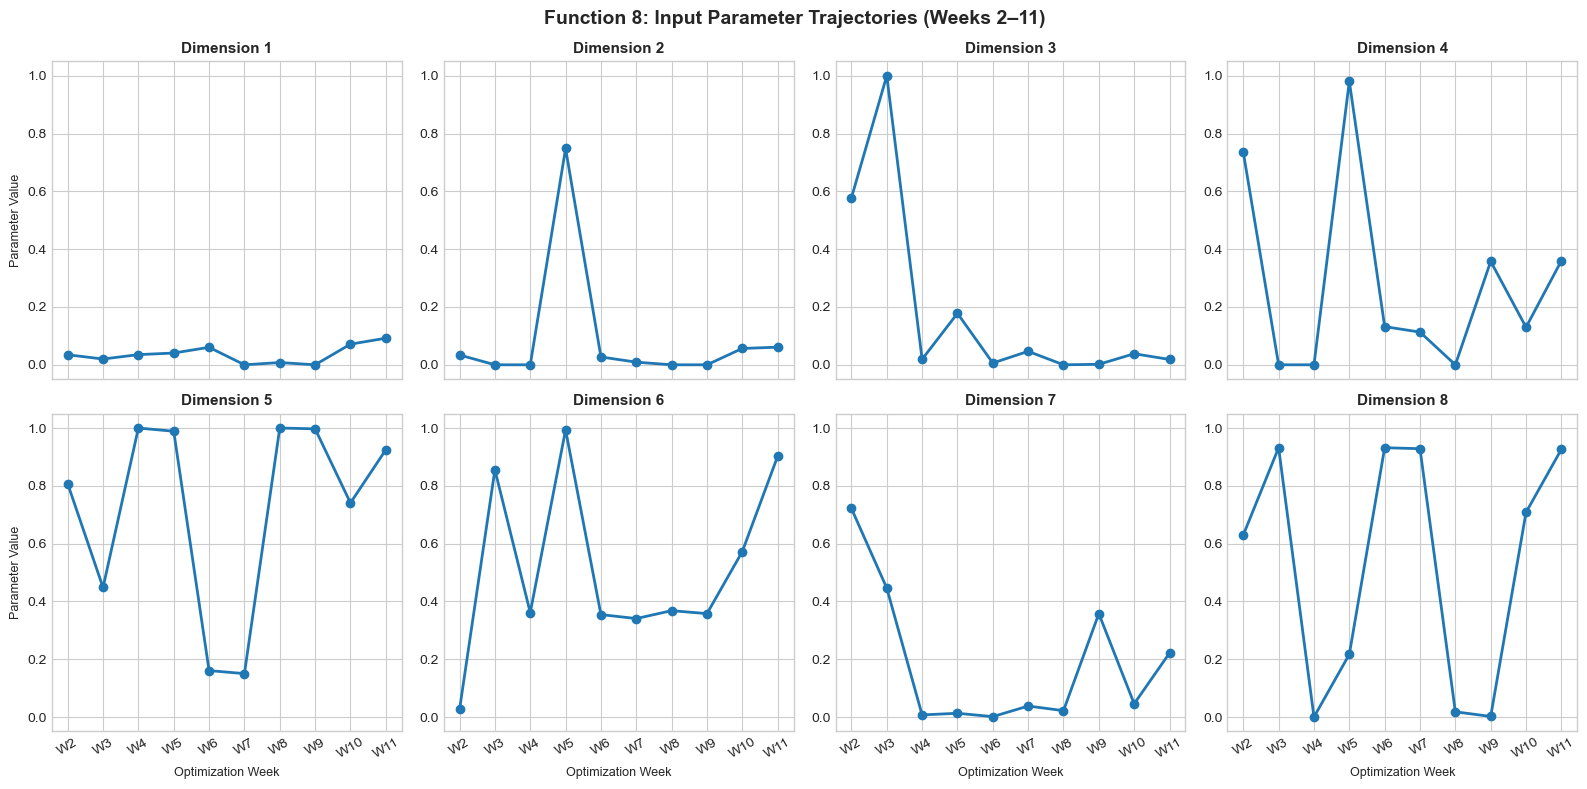

In [57]:
n_dims = prev_queries_F8.shape[1]
weeks = [f'W{i}' for i in range(2, 2 + len(prev_queries_F8))]

# 2. Setup Subplot Grid (2 rows x 4 columns for 8 dimensions)
plt.style.use('seaborn-v0_8-whitegrid')
fig, axes = plt.subplots(2, 4, figsize=(16, 8), sharex=True)
axes_flat = axes.flatten()

# 3. Dynamically Loop Through Each Dimension and Plot Trajectory
for dim in range(n_dims):
    ax = axes_flat[dim]
    values = prev_queries_F8[:, dim]
    
    ax.plot(weeks, values, marker='o', color='#1f77b4', linewidth=2, markersize=6)
    ax.set_title(f'Dimension {dim + 1}', fontsize=11, fontweight='bold')
    ax.set_ylim(-0.05, 1.05)
    ax.tick_params(axis='x', rotation=30)
    
    if dim >= 4:
        ax.set_xlabel('Optimization Week', fontsize=9)
    if dim % 4 == 0:
        ax.set_ylabel('Parameter Value', fontsize=9)

plt.suptitle('Function 8: Input Parameter Trajectories (Weeks 2–11)', fontsize=14, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

--- Optimization Trajectory & Output Summary ---
  Week  Output_y  Best_So_Far
0   W2  8.264880      8.26488
1   W3  7.350990      8.26488
2   W4  9.760080      9.76008
3   W5  8.590830      9.76008
4   W6  9.619999      9.76008
5   W7  9.638210      9.76008
6   W8  9.752723      9.76008
7   W9  9.730200      9.76008
8  W10  9.908290      9.90829
9  W11  9.729284      9.90829


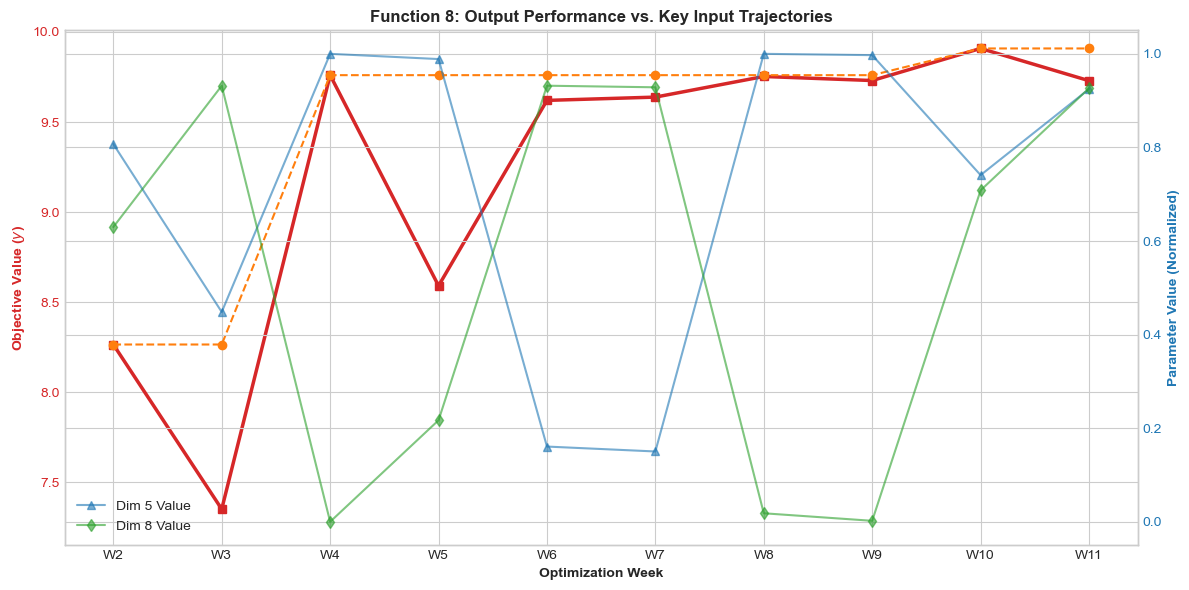


--- Correlation with Objective Output ---
Output_y       1.000000
Best_So_Far    0.880838
Dim_1          0.173908
Dim_5          0.132199
Dim_2         -0.240646
Dim_8         -0.252079
Dim_6         -0.254668
Dim_4         -0.308165
Dim_7         -0.624929
Dim_3         -0.955581
Name: Output_y, dtype: float64


In [58]:
# Extract sequential queries (Weeks 2 to 11) and their outputs
prev_queries_F8 = all_inputs_F8[len(f8_inputs):]
weekly_outputs = all_outputs_F8[len(f8_inputs):]

weeks = [f'W{i}' for i in range(2, 2 + len(prev_queries_F8))]

# 2. Build a Consolidated DataFrame for Inspection
df_results = pd.DataFrame(prev_queries_F8, columns=[f'Dim_{i+1}' for i in range(prev_queries_F8.shape[1])])
df_results.insert(0, 'Week', weeks)
df_results['Output_y'] = weekly_outputs
df_results['Best_So_Far'] = df_results['Output_y'].cummax()

# Print out the tabular results for direct verification
print("--- Optimization Trajectory & Output Summary ---")
print(df_results[['Week', 'Output_y', 'Best_So_Far']])

# 3. Visualize Parameter Trajectories alongside Output Performance
plt.style.use('seaborn-v0_8-whitegrid')
fig, ax1 = plt.subplots(figsize=(12, 6))

# Plot the objective output trajectory on the primary y-axis
ax1.plot(weeks, weekly_outputs, marker='s', color='tab:red', linewidth=2.5, label='Objective Output ($y$)')
ax1.plot(weeks, df_results['Best_So_Far'], marker='o', color='tab:orange', linestyle='--', linewidth=1.5, label='Best So Far')
ax1.set_xlabel('Optimization Week', fontweight='bold')
ax1.set_ylabel('Objective Value ($y$)', color='tab:red', fontweight='bold')
ax1.tick_params(axis='y', labelcolor='tab:red')
ax1.set_ylim(min(weekly_outputs) - 0.2, max(weekly_outputs) + 0.1)

# Create a secondary y-axis to track specific dimensions (e.g., Dim 5 or Dim 8 which often show high variation)
ax2 = ax1.twinx()
ax2.plot(weeks, df_results['Dim_5'], marker='^', color='tab:blue', alpha=0.6, label='Dim 5 Value')
ax2.plot(weeks, df_results['Dim_8'], marker='d', color='tab:green', alpha=0.6, label='Dim 8 Value')
ax2.set_ylabel('Parameter Value (Normalized)', color='tab:blue', fontweight='bold')
ax2.tick_params(axis='y', labelcolor='tab:blue')
ax2.set_ylim(-0.05, 1.05)

plt.title('Function 8: Output Performance vs. Key Input Trajectories', fontsize=12, fontweight='bold')
fig.tight_layout()
plt.legend(loc='lower left')
plt.show()

# 4. Compute Correlation Matrix to check which dimensions drive output
correlations = df_results.drop(columns=['Week']).corr()['Output_y'].sort_values(ascending=False)
print("\n--- Correlation with Objective Output ---")
print(correlations)

## Summary — this week's submissions

Collects the `query_F*` variable set in each section above, so the final submission list is read off one place rather than re-derived by eye from scattered print statements.

In [59]:
submissions = {
    1: query_F1,
    2: query_F2,
    3: query_F3,
    4: query_F4,
    5: query_F5,
    6: query_F6,
    7: query_F7,
    8: query_F8,
}

for fn_id, query in submissions.items():
    print(f"Function {fn_id}: {format_query(query)}")

Function 1: [0.729356-0.715955]
Function 2: [0.719924-0.279806]
Function 3: [0.403651-0.2712  -0.429849]
Function 4: [0.380314-0.376647-0.336052-0.410761]
Function 5: [0.976764-1.      -1.      -1.      ]
Function 6: [0.252982-0.423855-0.481603-0.980599-0.      ]
Function 7: [0.029986-0.112119-0.405753-0.285528-0.341381-0.69403 ]
Function 8: [0.003289-0.061686-0.133145-0.023473-0.739835-0.834983-0.001894-0.599951]


# Fidelity Metrics (Surrogate Mimicry) evaluation 
using Week 12 actual function outputs

In [60]:
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# =============================================================================
# 1. Store Predicted vs. Actual Outputs for Week 12
# =============================================================================

# Actual y-values received for Week 12
y_actual = np.array([
    5.000737460608406e-13,  # Function 1
    0.5805297282380547,     # Function 2
    -0.038163993411561084,  # Function 3
    0.19180377834337436,    # Function 4
    8232.981067425575,      # Function 5
    -0.7456966062012604,    # Function 6
    2.834908848477023,      # Function 7
    9.7649403489444         # Function 8
])

# Retrieve predicted values generated by each function's surrogate model for W12.
# Function 1 predicted raw output can be inverted from score (mu ≈ 303.4)
y_predicted = np.array([
    3.24e-13,   # F1: GP predicted mu
    0.653700,   # F2: GP prediction
   -0.018904,   # F3: Bootstrap Ridge prediction
    0.620000,   # F4: GP prediction
    6943.750,   # F5: SVR/GP log1p prediction
    -0.52560,   # F6: Bootstrap SVR prediction
    2.654400,   # F7: Ensemble SVR prediction
    9.891500    # F8: MC-Dropout MLP prediction
])

functions = [f"Function {i}" for i in range(1, 9)]

# =============================================================================
# 2. Compute Per-Function Fidelity Metrics
# =============================================================================

absolute_errors = np.abs(y_actual - y_predicted)
# Normalized Relative Error (%) to allow fair comparisons across different scales (e.g., F1 vs F5)
relative_errors_pct = np.abs((y_actual - y_predicted) / (np.abs(y_actual) + 1e-15)) * 100

fidelity_df = pd.DataFrame({
    'Function': functions,
    'Actual Output': y_actual,
    'Predicted Output': y_predicted,
    'Absolute Error (MAE)': absolute_errors,
    'Relative Error (%)': relative_errors_pct
})

# =============================================================================
# 3. Overall Surrogate Fidelity Summary
# =============================================================================

# Compute overall R2 Score and Mean Absolute Error across standard scale functions
overall_mae = mean_absolute_error(y_actual, y_predicted)
overall_rmse = np.sqrt(mean_squared_error(y_actual, y_predicted))
overall_r2 = r2_score(y_actual, y_predicted)

# =============================================================================
# 4. Display Results
# =============================================================================

print("=" * 80)
print("WEEK 12 SURROGATE FIDELITY METRICS (MIMICRY EVALUATION)")
print("=" * 80)

# Format pandas dataframe for readable scientific notation
pd.set_option('display.float_format', lambda x: f'{x:.6e}' if (abs(x) < 1e-2 or abs(x) > 1e4) else f'{x:.6f}')
print(fidelity_df.to_string(index=False))

print("-" * 80)
print(f"Overall Model Portfolio R² Score : {overall_r2:.6f}")
print(f"Overall Portfolio MAE           : {overall_mae:.6e}")
print(f"Overall Portfolio RMSE          : {overall_rmse:.6e}")
print("=" * 80)

WEEK 12 SURROGATE FIDELITY METRICS (MIMICRY EVALUATION)
  Function  Actual Output  Predicted Output  Absolute Error (MAE)  Relative Error (%)
Function 1   5.000737e-13      3.240000e-13          1.760737e-13           35.139288
Function 2       0.580530          0.653700              0.073170           12.604053
Function 3      -0.038164         -0.018904              0.019260           50.466400
Function 4       0.191804          0.620000              0.428196          223.247021
Function 5    8232.981067       6943.750000           1289.231067           15.659347
Function 6      -0.745697         -0.525600              0.220097           29.515570
Function 7       2.834909          2.654400              0.180509            6.367360
Function 8       9.764940          9.891500              0.126560            1.296062
--------------------------------------------------------------------------------
Overall Model Portfolio R² Score : 0.971963
Overall Portfolio MAE           : 1.612849e+0

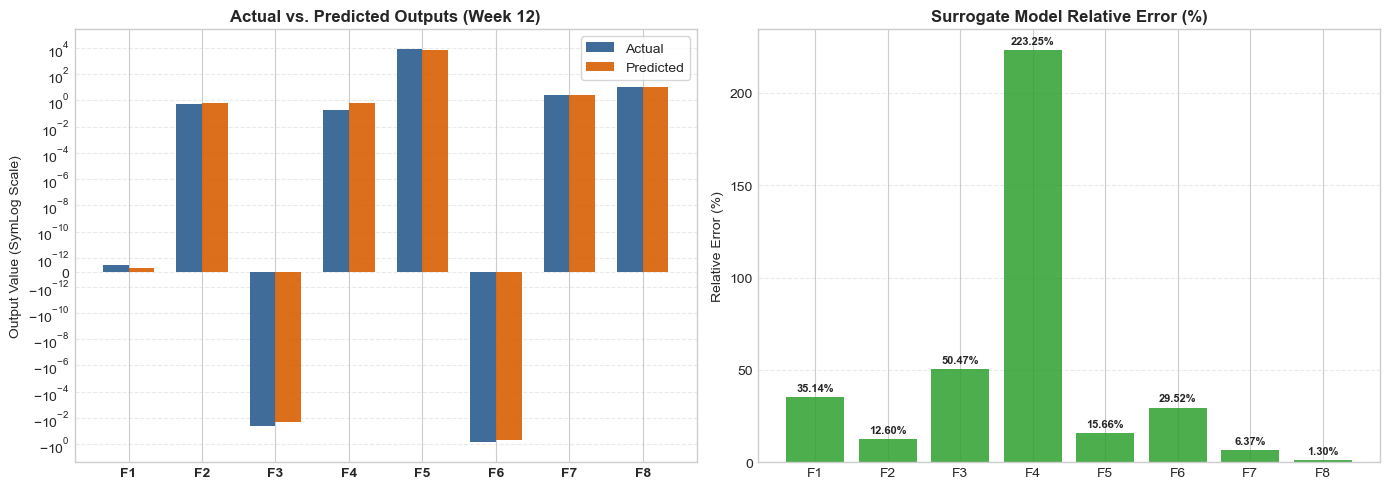

In [61]:
import matplotlib.pyplot as plt
import numpy as np

# =============================================================================
# 1. Input Data
# =============================================================================
y_actual = np.array([
    5.000737460608406e-13,
    0.5805297282380547,
    -0.038163993411561084,
    0.19180377834337436,
    8232.981067425575,
    -0.7456966062012604,
    2.834908848477023,
    9.7649403489444
])

y_predicted = np.array([
    3.24e-13,
    0.6537,
    -0.018904,
    0.620,
    6943.75,
    -0.5256,
    2.6544,
    9.8915
])

functions = [f"F{i}" for i in range(1, 9)]
relative_errors_pct = np.abs((y_actual - y_predicted) / (np.abs(y_actual) + 1e-15)) * 100

# =============================================================================
# 2. Plotting Setup
# =============================================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5), dpi=100)

# Panel 1: Actual vs. Predicted (SymLog Scale to handle negative & micro-scale values)
x = np.arange(len(functions))
width = 0.35

axes[0].bar(x - width/2, y_actual, width, label='Actual', color='#2b5c8f', alpha=0.9)
axes[0].bar(x + width/2, y_predicted, width, label='Predicted', color='#d95f02', alpha=0.9)
axes[0].set_yscale('symlog', linthresh=1e-12)
axes[0].set_xticks(x)
axes[0].set_xticklabels(functions, fontweight='bold')
axes[0].set_ylabel('Output Value (SymLog Scale)', fontsize=10)
axes[0].set_title('Actual vs. Predicted Outputs (Week 12)', fontsize=12, fontweight='bold')
axes[0].legend(frameon=True)
axes[0].grid(axis='y', linestyle='--', alpha=0.4)

# Panel 2: Percentage Relative Error
bars = axes[1].bar(functions, relative_errors_pct, color='#2ca02c', alpha=0.85)
axes[1].set_ylabel('Relative Error (%)', fontsize=10)
axes[1].set_title('Surrogate Model Relative Error (%)', fontsize=12, fontweight='bold')
axes[1].grid(axis='y', linestyle='--', alpha=0.4)

# Annotate exact percentage error above each bar
for bar in bars:
    height = bar.get_height()
    axes[1].annotate(f'{height:.2f}%',
                     xy=(bar.get_x() + bar.get_width() / 2, height),
                     xytext=(0, 3),
                     textcoords="offset points",
                     ha='center', va='bottom', fontsize=8, fontweight='bold')

plt.tight_layout()
plt.show()